# GUPPY PIPELINE 

# Generate plots of each trial where the FP signal is cut to the timeframe of the ethovision video, and it is plotted against an ethogram of the ethovision video

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# ==========================================================
# Automated EPM + Fiber Photometry pipeline
# Flexible to zone numbering & header differences
# ==========================================================

# ----------------------------------------------------------
# Main configuration
# ----------------------------------------------------------

main_dir = Path(".").resolve()
timepoints = ["Preinduction", "W1", "W2", "W3"]

# Nose-point zone substrings (FLEXIBLE MATCHING)
nosepoint_substrings = [
    "Arena / Nose-point",         # NEW
    "O1_prevC1 / Nose-point",
    "O2_prevC2 / Nose-point",
    "C1_prevO1 / Nose-point",
    "C2_prevO2 / Nose-point",
    "NeutralZone / Nose-point",
]

# Fixed colors keyed by inner substring (order doesn’t matter)
zone_colors = {
    "Arena / Nose-point": "#999999",         # grey
    "O1_prevC1 / Nose-point": "#E41A1C",     # red
    "O2_prevC2 / Nose-point": "#377EB8",     # blue
    "C1_prevO1 / Nose-point": "#4DAF4A",     # green
    "C2_prevO2 / Nose-point": "#984EA3",     # purple
    "NeutralZone / Nose-point": "#FF7F00",   # orange
}

video_fps = 50.0
fp_fps = 50.0

figures_main_dir = main_dir / "Figures"
figures_main_dir.mkdir(parents=True, exist_ok=True)

# ==========================================================
# Helper functions
# ==========================================================

def _mouse_genotype_tag(mouse_id: str):
    id_clean = mouse_id.strip()
    if id_clean in {"372", "376", "423"}:
        return "NE"
    if id_clean in {"374", "429"}:
        return "WT"
    return None


def _read_export_and_get_fp_and_mouse_id(xl_path: Path):
    df = pd.read_excel(xl_path, header=None)
    key_col = df.iloc[:, 0].astype(str).str.strip().str.lower()

    # FP file
    match_fp = df[key_col == "fp file"]
    if match_fp.empty:
        raise ValueError(f"'FP file' not found in {xl_path.name}")
    fp_id = str(df.iloc[match_fp.index[0], 1]).strip()

    # Mouse ID
    match_id = df[key_col == "id"]
    if match_id.empty:
        raise ValueError(f"'ID' row not found in {xl_path.name}")
    mouse_id = str(df.iloc[match_id.index[0], 1]).strip()

    return fp_id, mouse_id


def _find_fp_and_timestamp_files(fp_folder: Path, fp_id: str):
    fp_csv = None
    for p in fp_folder.glob("*.csv"):
        if fp_id.lower() in p.name.lower():
            #fp_csv = p
            fil = fp_id + '.csv'
            fp_csv = fp_folder / fil
            break
    if fp_csv is None:
        raise FileNotFoundError(f"No FP CSV found in {fp_folder}")

    ts_csv = None
    for p in fp_folder.glob("*.csv"):
        if "time" in p.name.lower() or "timestamp" in p.name.lower():
            #ts_csv = p
            import os
            directory, filename = os.path.split(p)

            # Remove leading "._" if present
            new_filename = filename.lstrip("._") if filename.startswith("._") else filename

            # Join back together
            new_path = os.path.join(directory, new_filename)
            
            ts_csv = new_path
            break
    if ts_csv is None:
        raise FileNotFoundError(f"No timestamp CSV found in {fp_folder}")

    return fp_csv, ts_csv


def _coerce_bool_col(series):
    if series.dtype == bool:
        return series
    if pd.api.types.is_numeric_dtype(series):
        return (series.astype(float) > 0).astype(bool)
    low = series.astype(str).str.strip().str.lower()
    return low.isin(["true", "1", "t", "yes", "y"])


def _get_video_window(ts: pd.DataFrame):
    """Robust detection of video ON/OFF timestamps."""
    # Time column
    tcol = next(c for c in ts.columns if "time" in c.lower())
    t = pd.to_numeric(ts[tcol], errors="coerce")

    # Digital channel
    scol = None
    for c in ts.columns:
        if "digital" in c.lower() or "state" in c.lower():
            scol = c
            break

    # No digital info → use full recording
    if scol is None:
        return float(t.iloc[0]), float(t.iloc[-1])

    state = _coerce_bool_col(ts[scol])

    # If no transitions → full interval
    if state.sum() == 0 or (~state).sum() == 0:
        return float(t.iloc[0]), float(t.iloc[-1])

    # Use first True and first False
    try:
        video_start = float(t[state].iloc[0])
        video_stop = float(t[~state].iloc[0])
        if video_stop > video_start:
            return video_start, video_stop
    except:
        pass

    # Fallback
    return float(t.iloc[0]), float(t.iloc[-1])


def _build_time_vector_from_fp(fp_df):
    if "SystemTimestamp" in fp_df.columns:
        ts = pd.to_numeric(fp_df["SystemTimestamp"], errors="coerce")
        if ts.notna().sum() > len(ts) * 0.8:
            return ts.to_numpy()
    return np.arange(len(fp_df)) / fp_fps


def _snap_down_index(t, target):
    return max(0, np.searchsorted(t, target, side="right") - 1)


def _trim_fp_to_window(fp_df, start, stop):
    tt = _build_time_vector_from_fp(fp_df)
    if len(tt) != len(fp_df):
        n = min(len(tt), len(fp_df))
        tt = tt[:n]
        fp_df = fp_df.iloc[:n]

    i0 = _snap_down_index(tt, start)
    i1 = _snap_down_index(tt, stop)
    out = fp_df.iloc[i0:i1+1].copy()
    out["Time_video"] = tt[i0:i1+1] - tt[i0]
    return out


def _detect_header_row(eth_path: Path):
    preview = pd.read_excel(eth_path, header=None, nrows=50)

    firstcell = str(preview.iloc[0, 0])
    if "number of header lines" in firstcell.lower():
        m = re.findall(r"\d+", firstcell)
        if m:
            return int(m[0])

    col0 = preview.iloc[:, 0].astype(str)
    hits = col0[col0.str.contains("Trial time", case=False, na=False)]
    if not hits.empty:
        return hits.index[0]

    raise ValueError(f"Cannot detect header row in {eth_path.name}")


def _load_ethovision_sheet_with_targets(eth_path: Path, video_fps: float):
    header_row = _detect_header_row(eth_path)
    eth = pd.read_excel(eth_path, header=header_row).dropna(axis=1, how="all")

    # Time_s
    tcol = next((c for c in eth.columns if "time" in c.lower()), None)
    if tcol:
        eth["Time_s"] = pd.to_numeric(eth[tcol], errors="coerce")
    else:
        eth["Time_s"] = np.arange(len(eth)) / video_fps

    # Flexible matching of nose-point zone columns
    matched_cols = []
    for sub in nosepoint_substrings:
        for col in eth.columns:
            if sub in str(col):
                matched_cols.append(col)
                break

    if not matched_cols:
        raise ValueError(f"No nose-point zones found in {eth_path.name}")

    return eth[["Time_s"] + matched_cols].copy(), matched_cols


def _ethogram_segments(eth, beh_cols):
    segments = []
    for beh in beh_cols:
        mask = eth[beh] == 1
        if mask.sum() == 0:
            continue
        diff = mask.astype(int).diff().fillna(0)
        starts = eth.loc[diff == 1, "Time_s"]
        ends = eth.loc[diff == -1, "Time_s"]

        if mask.iloc[0]:
            starts = pd.concat([pd.Series([eth["Time_s"].iloc[0]]), starts])
        if mask.iloc[-1]:
            ends = pd.concat([ends, pd.Series([eth["Time_s"].iloc[-1]])])

        for s, e in zip(starts, ends):
            segments.append(
                {"Behavior": beh, "Start_time_s": float(s), "End_time_s": float(e),
                 "Duration_s": float(e - s)}
            )
    return pd.DataFrame(segments)


def _guess_zone_color(colname):
    for sub, color in zone_colors.items():
        if sub in colname:
            return color
    return "black"


def _plot_trial(fp_trim, eth_timeline, beh_cols, out_png, title_prefix):
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True,
                             gridspec_kw={"height_ratios": [2, 2, 1]})

    chan = "G0" if "G0" in fp_trim.columns else next(
        c for c in fp_trim.columns
        if pd.api.types.is_numeric_dtype(fp_trim[c])
        and c not in {"LedState", "SystemTimestamp", "Time_video", "Timestamp"}
    )

    # LED 1 – isosbestic
    fp1 = fp_trim[fp_trim["LedState"] == 1]
    axes[0].plot(fp1["Time_video"], fp1[chan], linewidth=0.8, color="gray")
    axes[0].set_title(f"{title_prefix}: LED 1 (isosbestic)")
    axes[0].grid(True)

    # LED 2 – GCaMP
    fp2 = fp_trim[fp_trim["LedState"] == 2]
    axes[1].plot(fp2["Time_video"], fp2[chan], linewidth=0.8, color="green")
    axes[1].set_title(f"{title_prefix}: LED 2 (GCaMP)")
    axes[1].grid(True)

    # Ethogram
    for i, beh in enumerate(beh_cols):
        color = _guess_zone_color(beh)
        subset = eth_timeline[eth_timeline["Behavior"] == beh]
        for _, row in subset.iterrows():
            axes[2].barh(i, row["Duration_s"], left=row["Start_time_s"],
                         height=0.6, color=color)

    axes[2].set_yticks(range(len(beh_cols)))
    axes[2].set_yticklabels(beh_cols)
    axes[2].invert_yaxis()
    axes[2].set_xlabel("Time (s)")
    axes[2].set_title("Time in zone (nose-point)")

    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close(fig)


def _extract_led_traces(fp_trim, chan):
    iso = fp_trim.loc[fp_trim["LedState"] == 1, ["Time_video", chan]].rename(
        columns={chan: f"{chan}_iso415"})
    gcamp = fp_trim.loc[fp_trim["LedState"] == 2, ["Time_video", chan]].rename(
        columns={chan: f"{chan}_gcamp470"})
    return iso.reset_index(drop=True), gcamp.reset_index(drop=True)


# ==========================================================
# Main loop
# ==========================================================

fp_traces = {}

for tp in timepoints:
    print(f"\n=== Processing timepoint: {tp} ===")
    tp_dir = main_dir / tp
    export_dir = tp_dir / "Export files"

    fig_dir_tp = figures_main_dir / tp
    fig_dir_raw = fig_dir_tp / "Raw_traces_ethograms"
    fig_dir_raw.mkdir(parents=True, exist_ok=True)

    trial_files = sorted(export_dir.glob("Raw data-*.xlsx"))
    if not trial_files:
        print(f"[WARN] No Raw data-*.xlsx files in {export_dir}")
        continue

    for eth_path in trial_files:
        try:
            fp_id, mouse_id = _read_export_and_get_fp_and_mouse_id(eth_path)
            geno = _mouse_genotype_tag(mouse_id)

            fp_folder = tp_dir / fp_id
            fp_csv, ts_csv = _find_fp_and_timestamp_files(fp_folder, fp_id)

            # Load FP
            fp = pd.read_csv(fp_csv, encoding="utf-8")
            fp = fp[fp["LedState"].isin([1, 2])]

            # Align timestamps
            ts = pd.read_csv(ts_csv, encoding="utf-8")
            video_start, video_stop = _get_video_window(ts)
            fp_trim = _trim_fp_to_window(fp, video_start, video_stop)

            # Detect channel
            chan = "G0" if "G0" in fp_trim.columns else next(
                c for c in fp_trim.columns
                if pd.api.types.is_numeric_dtype(fp_trim[c])
                and c not in {"LedState","SystemTimestamp","Time_video","Timestamp"}
            )

            iso_df, gcamp_df = _extract_led_traces(fp_trim, chan)

            trial_stub = eth_path.stem.replace("Raw data-", "").replace(" ", "_")
            mouse_label = f"ID{mouse_id}" + (f"_{geno}" if geno else "")
            file_stub = f"{mouse_label}__{fp_id}__{trial_stub}"

            fp_traces[f"{tp}__{file_stub}"] = {
                "iso": iso_df,
                "gcamp": gcamp_df,
                "mouse_id": mouse_id,
                "genotype": geno,
            }

            # Load EthoVision
            eth, matched_cols = _load_ethovision_sheet_with_targets(eth_path, video_fps)
            timeline = _ethogram_segments(eth, matched_cols) #timeline for behaviours

            # added this to store timeline to use in kernel smoothing in later code blocks
            # --- inside your main loop, after timeline is created ---
            #timeline = _ethogram_segments(eth, matched_cols)  # already there

            fp_traces[f"{tp}__{file_stub}"] = {
                "iso": iso_df,
                "gcamp": gcamp_df,
                "mouse_id": mouse_id,
                "genotype": geno,
                "timeline": timeline,   # <-- NEW: store timeline
                "beh_cols": matched_cols
            }


            # Plot trial
            out_png = fig_dir_raw / f"{file_stub}_zones.png"
            _plot_trial(fp_trim, timeline, matched_cols, out_png,
                        title_prefix=f"{mouse_label} | {fp_id} | {trial_stub}")

            print(f"✔ {eth_path.name} → {out_png.name}")

        except Exception as e:
            print(f"[WARN] [{tp}] {eth_path.name}: {e}")



=== Processing timepoint: Preinduction ===
✔ Raw data-EP_preinduction_BigArena-Trial     1.xlsx → ID376_NE__EPM_FP0__EP_preinduction_BigArena-Trial_____1_zones.png
✔ Raw data-EP_preinduction_BigArena-Trial     2.xlsx → ID372_NE__EPM_FP1__EP_preinduction_BigArena-Trial_____2_zones.png
✔ Raw data-EP_preinduction_BigArena-Trial     3.xlsx → ID374_WT__EPM_FP2__EP_preinduction_BigArena-Trial_____3_zones.png
✔ Raw data-EP_preinduction_BigArena-Trial     4.xlsx → ID429_WT__EPM_FP3__EP_preinduction_BigArena-Trial_____4_zones.png
✔ Raw data-EP_preinduction_BigArena-Trial     5.xlsx → ID423_NE__EPM_FP5__EP_preinduction_BigArena-Trial_____5_zones.png

=== Processing timepoint: W1 ===
✔ Raw data-EPM_W1_BigArena-Trial     1.xlsx → ID376_NE__EPM_FP0__EPM_W1_BigArena-Trial_____1_zones.png
✔ Raw data-EPM_W1_BigArena-Trial     2.xlsx → ID372_NE__EPM_FP1__EPM_W1_BigArena-Trial_____2_zones.png
✔ Raw data-EPM_W1_BigArena-Trial     3.xlsx → ID374_WT__EPM_FP2__EPM_W1_BigArena-Trial_____3_zones.png
✔ Raw da

In [3]:
list(fp_traces.keys())[:3]
first_key = next(iter(fp_traces))
fp_traces[first_key]


{'iso':        Time_video  G0_iso415
 0        0.020000   0.033076
 1        0.060000   0.033114
 2        0.100000   0.033101
 3        0.140000   0.033125
 4        0.180000   0.033103
 ...           ...        ...
 14992  599.699232   0.032974
 14993  599.739232   0.033018
 14994  599.779232   0.032936
 14995  599.819232   0.032882
 14996  599.859232   0.032918
 
 [14997 rows x 2 columns],
 'gcamp':        Time_video  G0_gcamp470
 0        0.000000     0.033753
 1        0.040000     0.033775
 2        0.080000     0.033609
 3        0.120000     0.033639
 4        0.160000     0.033542
 ...           ...          ...
 14993  599.719232     0.033428
 14994  599.759232     0.033444
 14995  599.799232     0.033576
 14996  599.839232     0.033434
 14997  599.879232     0.033725
 
 [14998 rows x 2 columns],
 'mouse_id': '376',
 'genotype': 'NE',
 'timeline':                                 Behavior  Start_time_s  End_time_s  Duration_s
 0          In zone 3(Arena / Nose-point)         0

In [4]:
import pandas as pd

fp_traces_df = pd.DataFrame.from_dict(fp_traces, orient="index")
fp_traces_df.head()


,iso,gcamp,mouse_id,genotype,timeline,beh_cols
Preinduction__ID376_NE__EPM_FP0__EP_preinduction_BigArena-Trial_____1,Time_video G0_iso415 0 0.020000...,Time_video G0_gcamp470 0 0.0000...,376,NE,Behavior Star...,"[In zone 3(Arena / Nose-point), In zone 3(O1_p..."
Preinduction__ID372_NE__EPM_FP1__EP_preinduction_BigArena-Trial_____2,Time_video G0_iso415 0 0.000000...,Time_video G0_gcamp470 0 0.0200...,372,NE,Behavior Star...,"[In zone 3(Arena / Nose-point), In zone 3(O1_p..."
Preinduction__ID374_WT__EPM_FP2__EP_preinduction_BigArena-Trial_____3,Time_video G0_iso415 0 0.02000...,Time_video G0_gcamp470 0 0.000...,374,WT,Behavior Star...,"[In zone 3(Arena / Nose-point), In zone 3(O1_p..."
Preinduction__ID429_WT__EPM_FP3__EP_preinduction_BigArena-Trial_____4,Time_video G0_iso415 0 0.020000...,Time_video G0_gcamp470 0 0.0000...,429,WT,Behavior Sta...,"[In zone 3(Arena / Nose-point), In zone 3(O1_p..."
Preinduction__ID423_NE__EPM_FP5__EP_preinduction_BigArena-Trial_____5,Time_video G0_iso415 0 0.020000...,Time_video G0_gcamp470 0 0.0000...,423,NE,Behavior Star...,"[In zone 3(Arena / Nose-point), In zone 3(O1_p..."


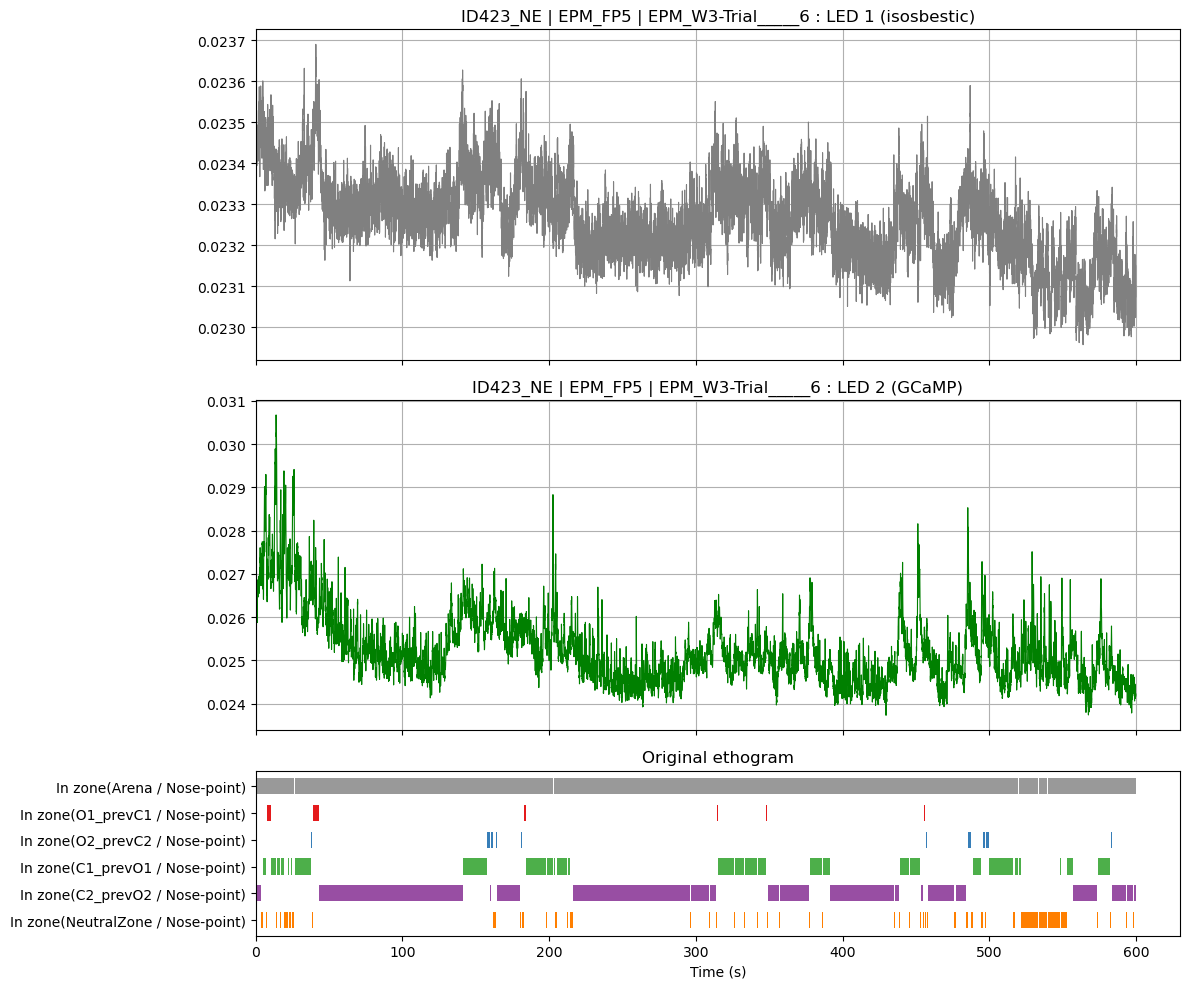

In [26]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True,
                         gridspec_kw={"height_ratios": [2, 2, 1]})

# --- FP traces ---
chan = "G0" if "G0" in fp_trim.columns else next(
    c for c in fp_trim.columns
    if pd.api.types.is_numeric_dtype(fp_trim[c])
    and c not in {"LedState","SystemTimestamp","Time_video","Timestamp"}
)

# LED 1
fp1 = fp_trim[fp_trim["LedState"] == 1]
axes[0].plot(fp1["Time_video"], fp1[chan], linewidth=0.8, color="gray")
axes[0].set_title(f"{mouse_label} | {fp_id} | {trial_stub} : LED 1 (isosbestic)")
axes[0].grid(True)

# LED 2
fp2 = fp_trim[fp_trim["LedState"] == 2]
axes[1].plot(fp2["Time_video"], fp2[chan], linewidth=0.8, color="green")
axes[1].set_title(f"{mouse_label} | {fp_id} | {trial_stub} : LED 2 (GCaMP)")
axes[1].grid(True)

# --- Original ethogram ---
beh_cols_orig = timeline["Behavior"].unique()
for i, beh in enumerate(beh_cols_orig):
    color = _guess_zone_color(beh)
    subset = timeline[timeline["Behavior"] == beh]
    for _, row in subset.iterrows():
        axes[2].barh(i, row["Duration_s"], left=row["Start_time_s"], height=0.6, color=color)

axes[2].set_yticks(range(len(beh_cols_orig)))
axes[2].set_yticklabels(beh_cols_orig)
axes[2].invert_yaxis()
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Original ethogram")

# --- Cleaned / collapsed ethogram ---
#beh_cols_clean = timeline_cleaned["Behavior"].unique()
#for i, beh in enumerate(beh_cols_clean):<
#    color = _guess_zone_color(beh)
#    subset = timeline_cleaned[timeline_cleaned["Behavior"] == beh]
#    for _, row in subset.iterrows():
#        axes[3].barh(i, row["Duration_s"], left=row["Start_time_s"], height=0.6, color=color)
#
#axes[3].set_yticks(range(len(beh_cols_clean)))
#axes[3].set_yticklabels(beh_cols_clean)
#axes[3].invert_yaxis()
#axes[3].set_xlabel("Time (s)")
#axes[3].set_title("Collapsed + cleaned ethogram")

plt.tight_layout()
plt.show()


In [27]:
timeline_filter = timeline[timeline['Behavior']  != 'In zone(Arena / Nose-point)'].sort_values('Start_time_s')
timeline_filter

,Behavior,Start_time_s,End_time_s,Duration_s
183,In zone(C2_prevO2 / Nose-point),0.000,3.521,3.521
268,In zone(NeutralZone / Nose-point),3.521,4.061,0.540
92,In zone(C1_prevO1 / Nose-point),4.061,4.421,0.360
269,In zone(NeutralZone / Nose-point),4.421,5.282,0.861
93,In zone(C1_prevO1 / Nose-point),5.282,7.162,1.880
...,...,...,...,...
265,In zone(C2_prevO2 / Nose-point),598.213,598.253,0.040
467,In zone(NeutralZone / Nose-point),598.253,598.694,0.441
266,In zone(C2_prevO2 / Nose-point),598.694,599.774,1.080
468,In zone(NeutralZone / Nose-point),599.774,599.934,0.160


Issues: 
- fix residual time introduced in arranged (add to last timestamp? next iteration start from previous?)

In [52]:
def smoothing_kernel(data, grainularity = 0.1, kernel_size = 5):
    """
    Smooths timeline data using a kernel.

    Args:
        data (pd.DataFrame): Timeline data.
        grainularity (float): The grainularity that the timeline data should be split up with (seconds).
        kernel_size (int): The number of 'frames' (defined by the grainularity) the kernel looks ahead 
        and behind when determining the new lable.

    Returns:
        pd.DataFrame: The timeline data reassembled with the new labels in the column 'kernel_label'.
    """
    timeline_exploded = pd.DataFrame({'timestamp' : [], 'label' : []})

    #def explode_timeline(timeline, grainularity):
    for _, row in data.iterrows():
        # timestamps = np.arange(row['Start_time_s'], row['End_time_s'], grainularity)
        timestamps = np.arange(row['Start_time_s'], row['End_time_s'] + grainularity, grainularity)

        labels = row['Behavior'] #* len(timestamps)

        timeline_exploded = pd.concat([timeline_exploded, 
                                       pd.DataFrame({'timestamp' : timestamps, 'label' : labels})])

    timeline_exploded = timeline_exploded.reset_index()

    kernel_content = []

    def most_common(lst):
        return max(set(lst), key=lst.count)

    new_labels = []

    for i, row in timeline_exploded.iterrows():
        if i < kernel_size:
            kernel_content = timeline_exploded[ : i + kernel_size]['label']

        elif i + kernel_size > len(timeline_exploded):
            kernel_content = timeline_exploded[i - (kernel_size - 1) : ]['label']

        else:
            kernel_content = timeline_exploded[i - (kernel_size - 1) : i + kernel_size]['label']
        
        new_labels.append(most_common(kernel_content.to_list()))

    timeline_exploded['kernel_label'] = new_labels

    current_label = ''

    timeline_kernel_labels = pd.DataFrame()

    # for i, row in timeline_exploded.iterrows():
    #     if current_label == row['kernel_label']:
    #         pass

    #     elif current_label == '':
    #         current_label = row['kernel_label']
    #         Start_time_s = row['timestamp']

    #     elif current_label != row['kernel_label']:
    #         timeline_kernel_labels = pd.concat([timeline_kernel_labels,
    #                                             pd.DataFrame({
    #                                                 'Behavior' : [current_label],
    #                                                 'Start_time_s' : [Start_time_s],
    #                                                 'End_time_s' : row['timestamp'],
    #                                                 'Duration_s' : row['timestamp'] - Start_time_s
    #                                             })])
    #         Start_time_s = row['timestamp']
    #         current_label = row['kernel_label']
    
    # After your existing loop that builds timeline_kernel_labels
    for i, row in timeline_exploded.iterrows():
        if current_label == row['kernel_label']:
            pass
        elif current_label == '':
            current_label = row['kernel_label']
            Start_time_s = row['timestamp']
        elif current_label != row['kernel_label']:
            timeline_kernel_labels = pd.concat([timeline_kernel_labels,
                                                pd.DataFrame({
                                                    'Behavior' : [current_label],
                                                    'Start_time_s' : [Start_time_s],
                                                    'End_time_s' : row['timestamp'],
                                                    'Duration_s' : row['timestamp'] - Start_time_s
                                                })])
            Start_time_s = row['timestamp']
            current_label = row['kernel_label']

    # --- Append the final segment ---
    if current_label != '':
        timeline_kernel_labels = pd.concat([timeline_kernel_labels,
                                            pd.DataFrame({
                                                'Behavior': [current_label],
                                                'Start_time_s': [Start_time_s],
                                                'End_time_s': [timeline_exploded['timestamp'].iloc[-1]],
                                                'Duration_s': [timeline_exploded['timestamp'].iloc[-1] - Start_time_s]
                                            })])


    return timeline_kernel_labels

timeline_filter = timeline[timeline['Behavior']  != 'In zone(Arena / Nose-point)'].sort_values('Start_time_s')
timeline_filter
timeline_kernel_labels = smoothing_kernel(timeline_filter, grainularity = 0.1, kernel_size = 5)

In [53]:
timeline_kernel_labels

,Behavior,Start_time_s,End_time_s,Duration_s
0,In zone(C2_prevO2 / Nose-point),0.000,3.521,3.521
0,In zone(NeutralZone / Nose-point),3.521,4.061,0.540
0,In zone(C1_prevO1 / Nose-point),4.061,4.421,0.360
0,In zone(NeutralZone / Nose-point),4.421,5.282,0.861
0,In zone(C1_prevO1 / Nose-point),5.282,7.162,1.880
...,...,...,...,...
0,In zone(NeutralZone / Nose-point),593.492,594.072,0.580
0,In zone(C2_prevO2 / Nose-point),594.072,597.913,3.841
0,In zone(NeutralZone / Nose-point),597.913,598.694,0.781
0,In zone(C2_prevO2 / Nose-point),598.694,599.934,1.240


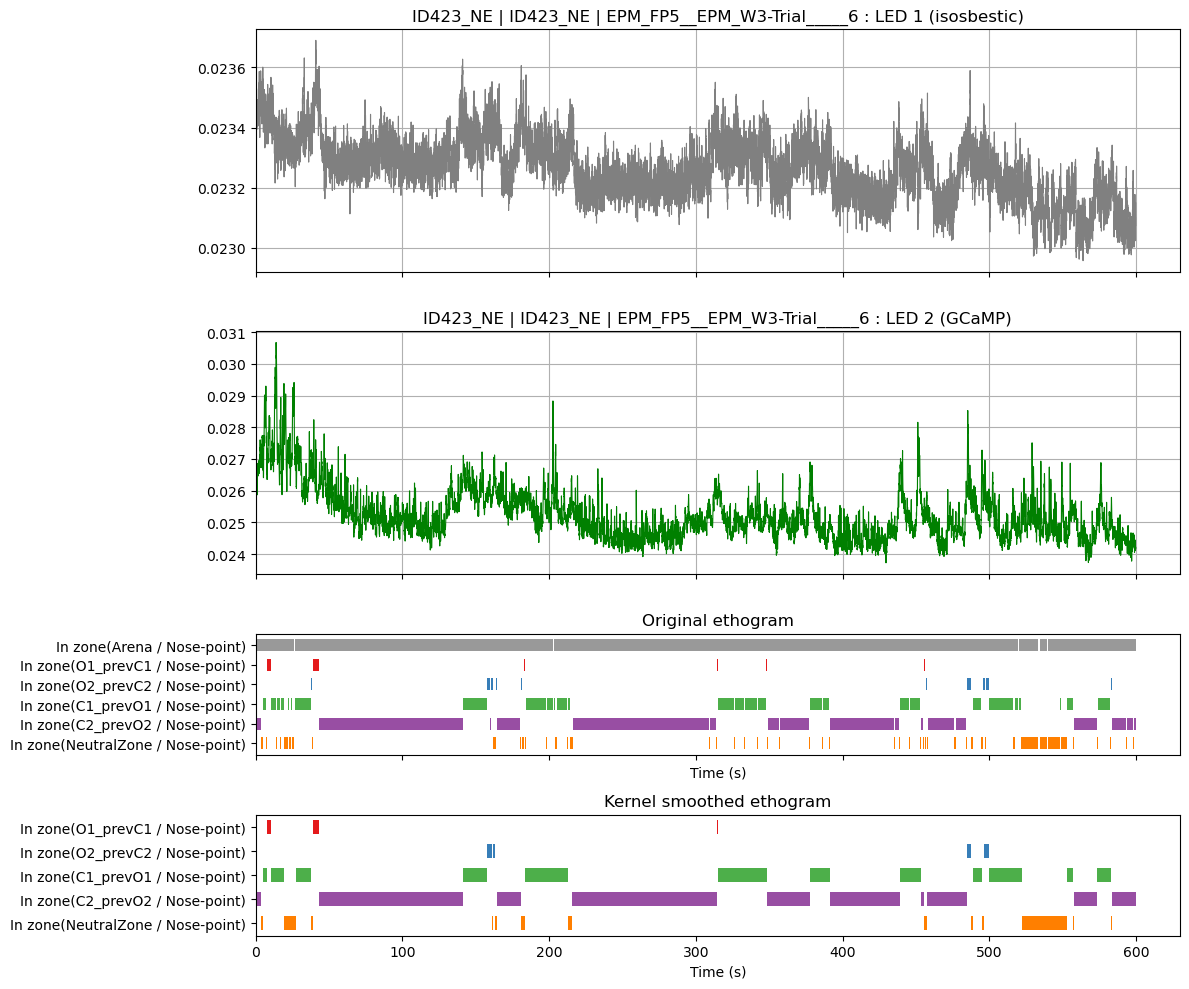

In [54]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True,
                         gridspec_kw={"height_ratios": [2, 2,1, 1]})

# --- FP traces ---
chan = "G0" if "G0" in fp_trim.columns else next(
    c for c in fp_trim.columns
    if pd.api.types.is_numeric_dtype(fp_trim[c])
    and c not in {"LedState","SystemTimestamp","Time_video","Timestamp"}
)

# LED 1
fp1 = fp_trim[fp_trim["LedState"] == 1]
axes[0].plot(fp1["Time_video"], fp1[chan], linewidth=0.8, color="gray")
axes[0].set_title(f"{mouse_label} | {fp_id} | {trial_stub} : LED 1 (isosbestic)")
axes[0].grid(True)

# LED 2
fp2 = fp_trim[fp_trim["LedState"] == 2]
axes[1].plot(fp2["Time_video"], fp2[chan], linewidth=0.8, color="green")
axes[1].set_title(f"{mouse_label} | {fp_id} | {trial_stub} : LED 2 (GCaMP)")
axes[1].grid(True)

# --- Original ethogram ---
beh_cols_orig = timeline["Behavior"].unique()
for i, beh in enumerate(beh_cols_orig):
    color = _guess_zone_color(beh)
    subset = timeline[timeline["Behavior"] == beh]
    for _, row in subset.iterrows():
        axes[2].barh(i, row["Duration_s"], left=row["Start_time_s"], height=0.6, color=color)

axes[2].set_yticks(range(len(beh_cols_orig)))
axes[2].set_yticklabels(beh_cols_orig)
axes[2].invert_yaxis()
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Original ethogram")

# --- Cleaned / collapsed ethogram ---
timeline_kernel_labels = smoothing_kernel(timeline_filter, grainularity = 0.1, kernel_size = 20) #play around with adjusting kernel size and granularity
#beh_cols_clean = timeline_kernel_labels["Behavior"].unique()
beh_cols_clean = [ # samme rækkefølge som plottet ovenfor
'In zone(O1_prevC1 / Nose-point)',
'In zone(O2_prevC2 / Nose-point)',
'In zone(C1_prevO1 / Nose-point)',
'In zone(C2_prevO2 / Nose-point)',
'In zone(NeutralZone / Nose-point)'
]
for i, beh in enumerate(beh_cols_clean):
    color = _guess_zone_color(beh)
    subset = timeline_kernel_labels[timeline_kernel_labels["Behavior"] == beh]
    for _, row in subset.iterrows():
        axes[3].barh(i, row["Duration_s"], left=row["Start_time_s"], height=0.6, color=color)

axes[3].set_yticks(range(len(beh_cols_clean)))
axes[3].set_yticklabels(beh_cols_clean)
axes[3].invert_yaxis()
axes[3].set_xlabel("Time (s)")
axes[3].set_title("Kernel smoothed ethogram")

plt.tight_layout()
plt.show()


# generate the above plot for all trials

In [55]:
#print(timeline_kernel_labels['Behavior'].unique())

print(timeline_kernel_labels['Behavior'])

0      In zone(C2_prevO2 / Nose-point)
0    In zone(NeutralZone / Nose-point)
0      In zone(C1_prevO1 / Nose-point)
0      In zone(O1_prevC1 / Nose-point)
0      In zone(C1_prevO1 / Nose-point)
0    In zone(NeutralZone / Nose-point)
0      In zone(C1_prevO1 / Nose-point)
0    In zone(NeutralZone / Nose-point)
0      In zone(O1_prevC1 / Nose-point)
0      In zone(C2_prevO2 / Nose-point)
0      In zone(C1_prevO1 / Nose-point)
0      In zone(O2_prevC2 / Nose-point)
0    In zone(NeutralZone / Nose-point)
0      In zone(O2_prevC2 / Nose-point)
0    In zone(NeutralZone / Nose-point)
0      In zone(O2_prevC2 / Nose-point)
0      In zone(C2_prevO2 / Nose-point)
0    In zone(NeutralZone / Nose-point)
0      In zone(C1_prevO1 / Nose-point)
0    In zone(NeutralZone / Nose-point)
0      In zone(C2_prevO2 / Nose-point)
0      In zone(O1_prevC1 / Nose-point)
0      In zone(C1_prevO1 / Nose-point)
0      In zone(C2_prevO2 / Nose-point)
0      In zone(C1_prevO1 / Nose-point)
0      In zone(C2_prevO2 

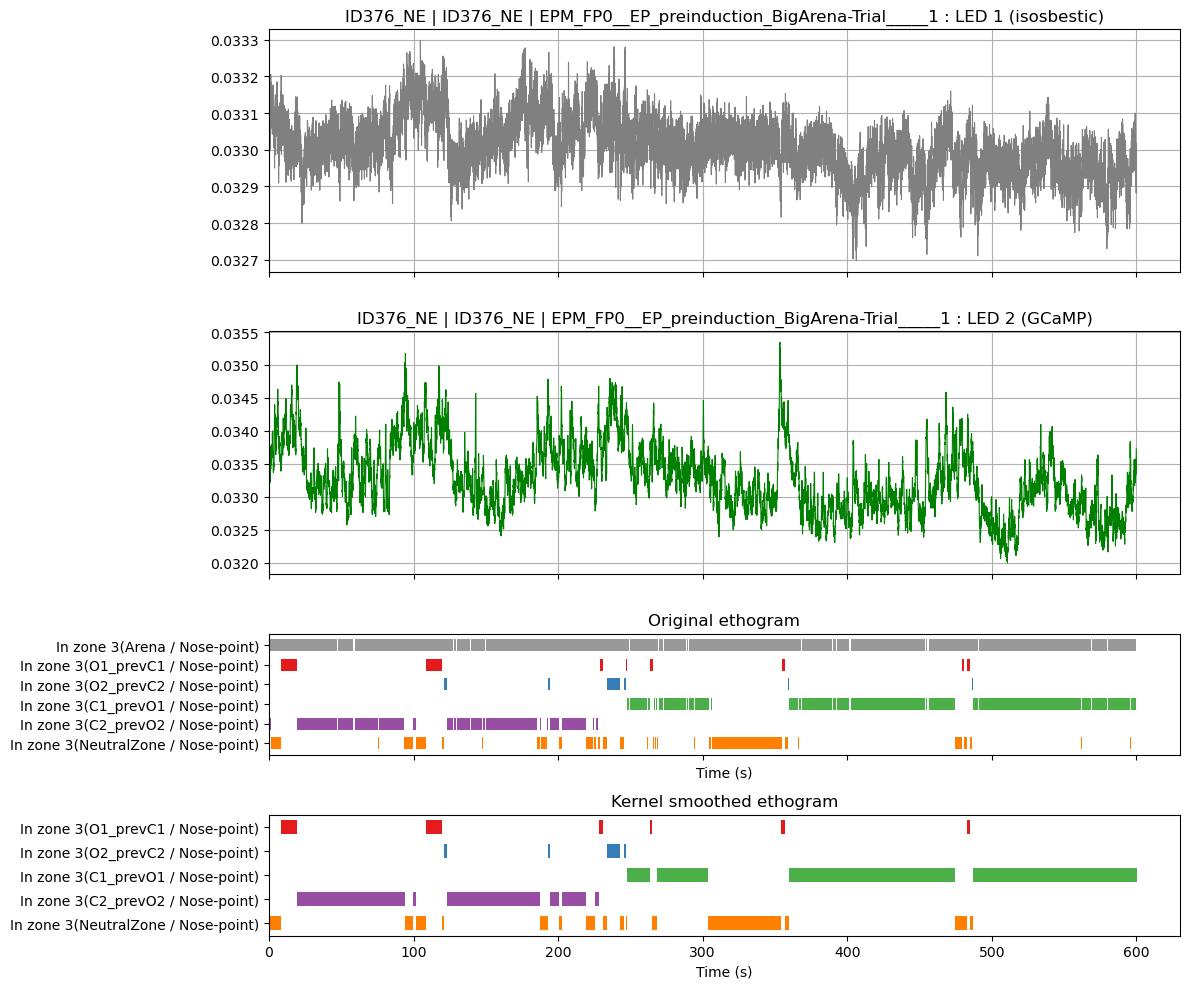

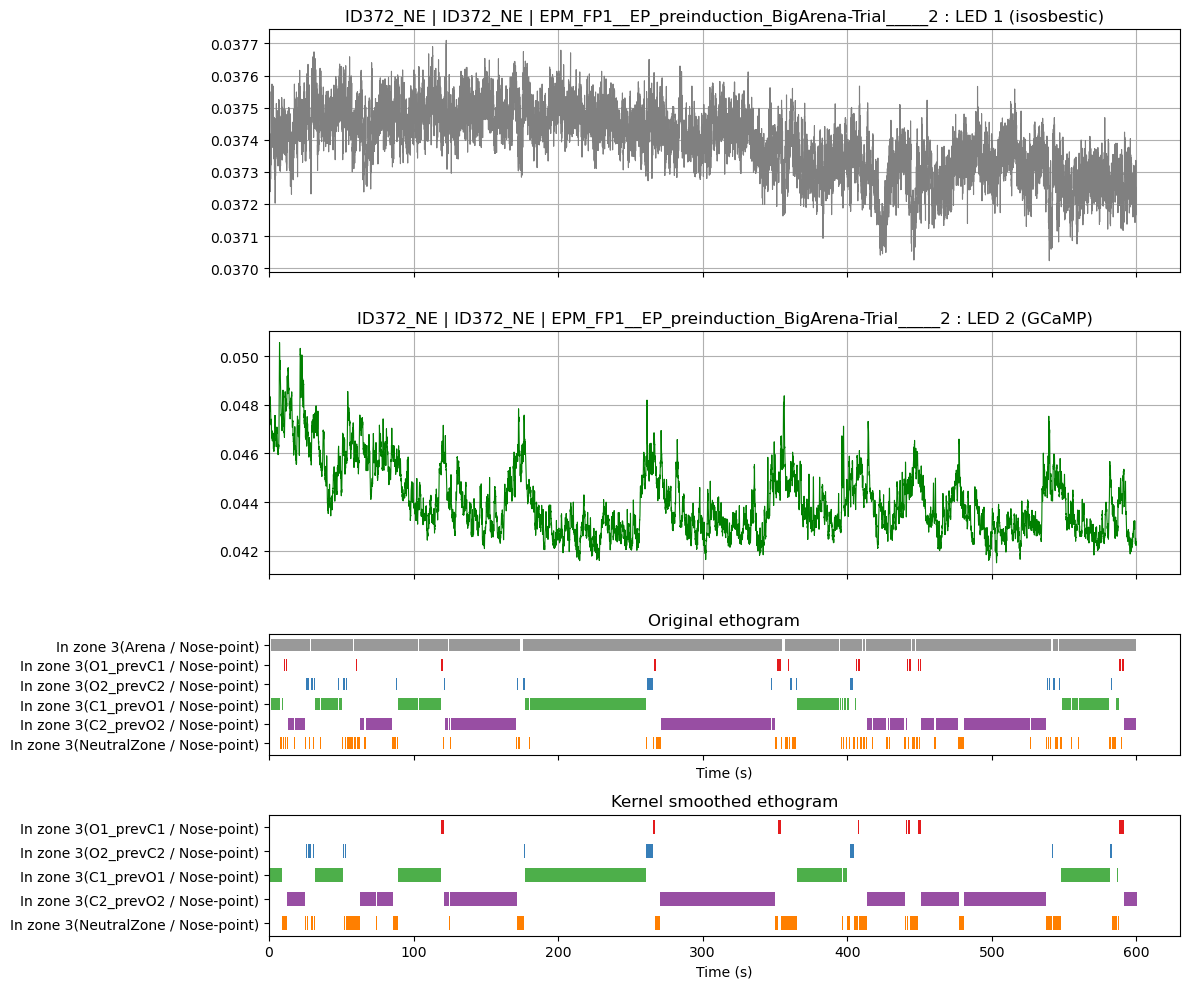

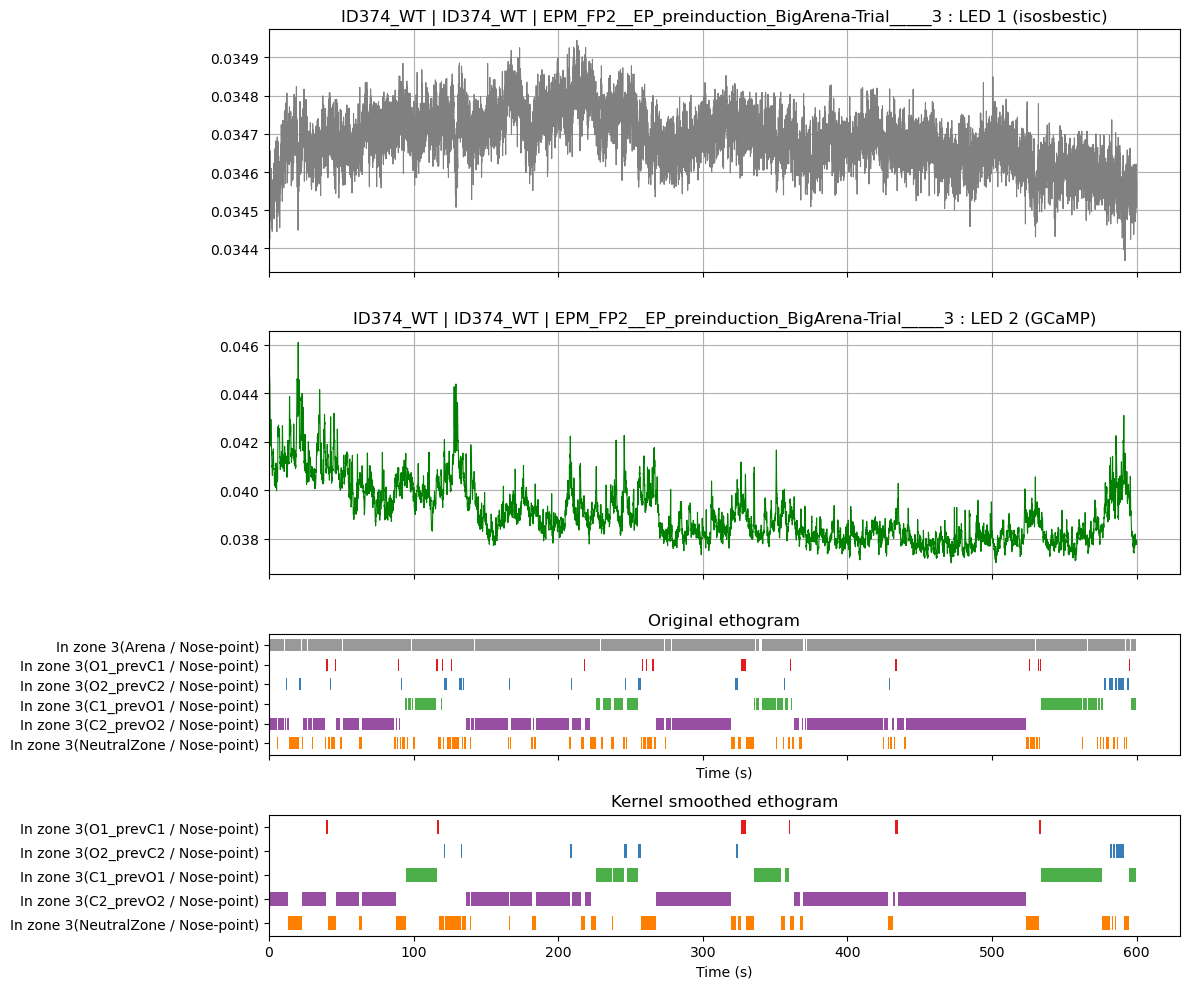

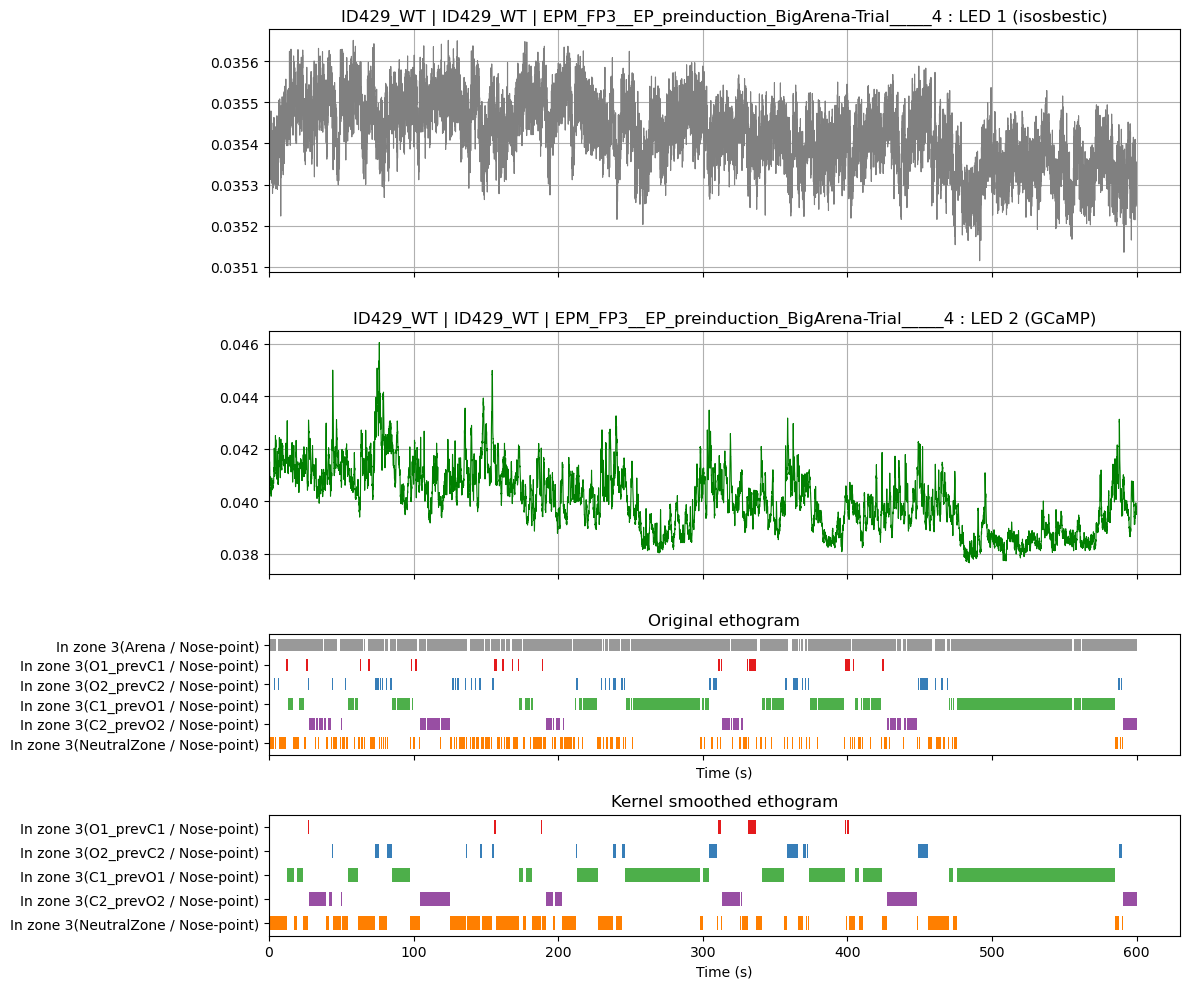

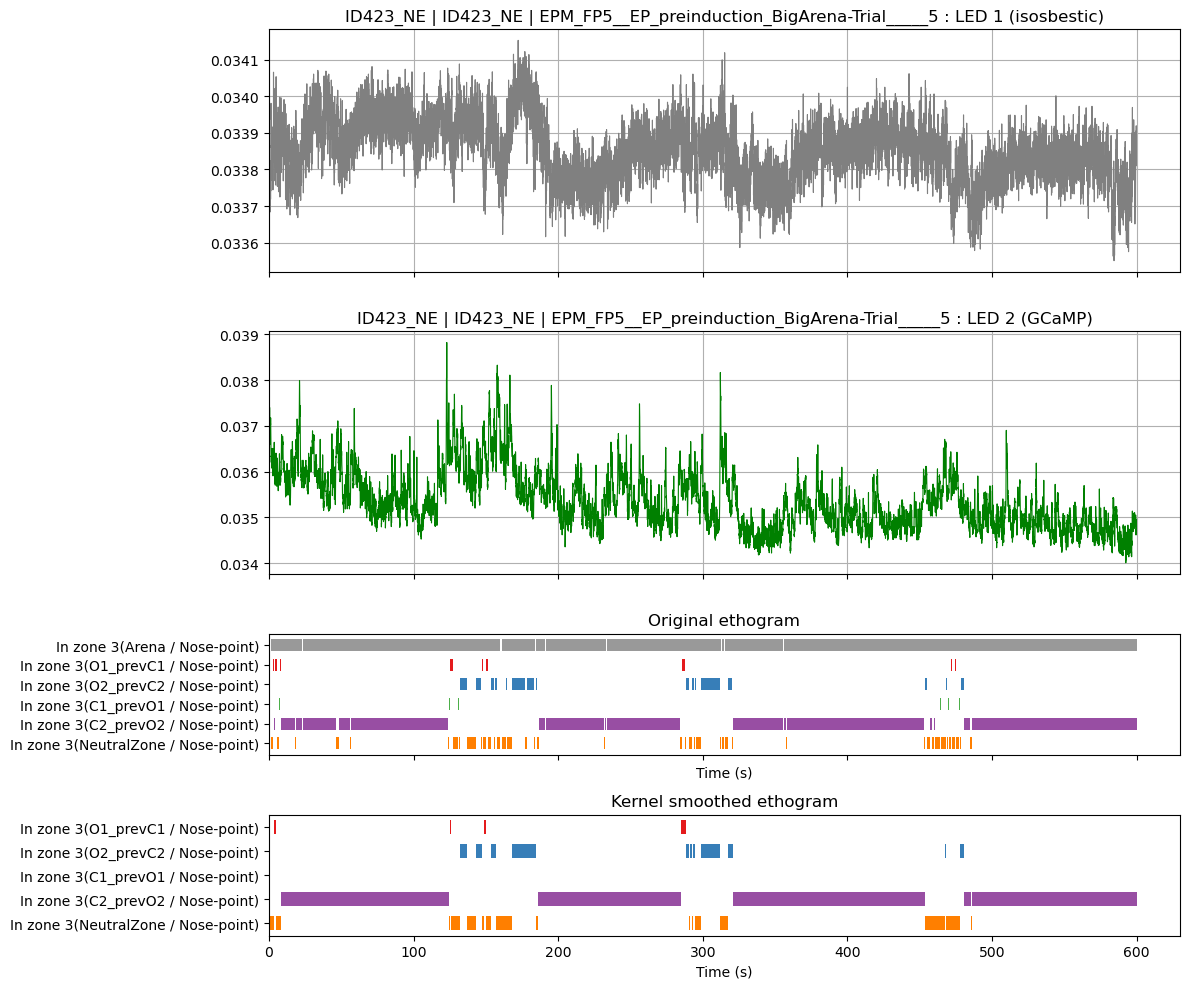

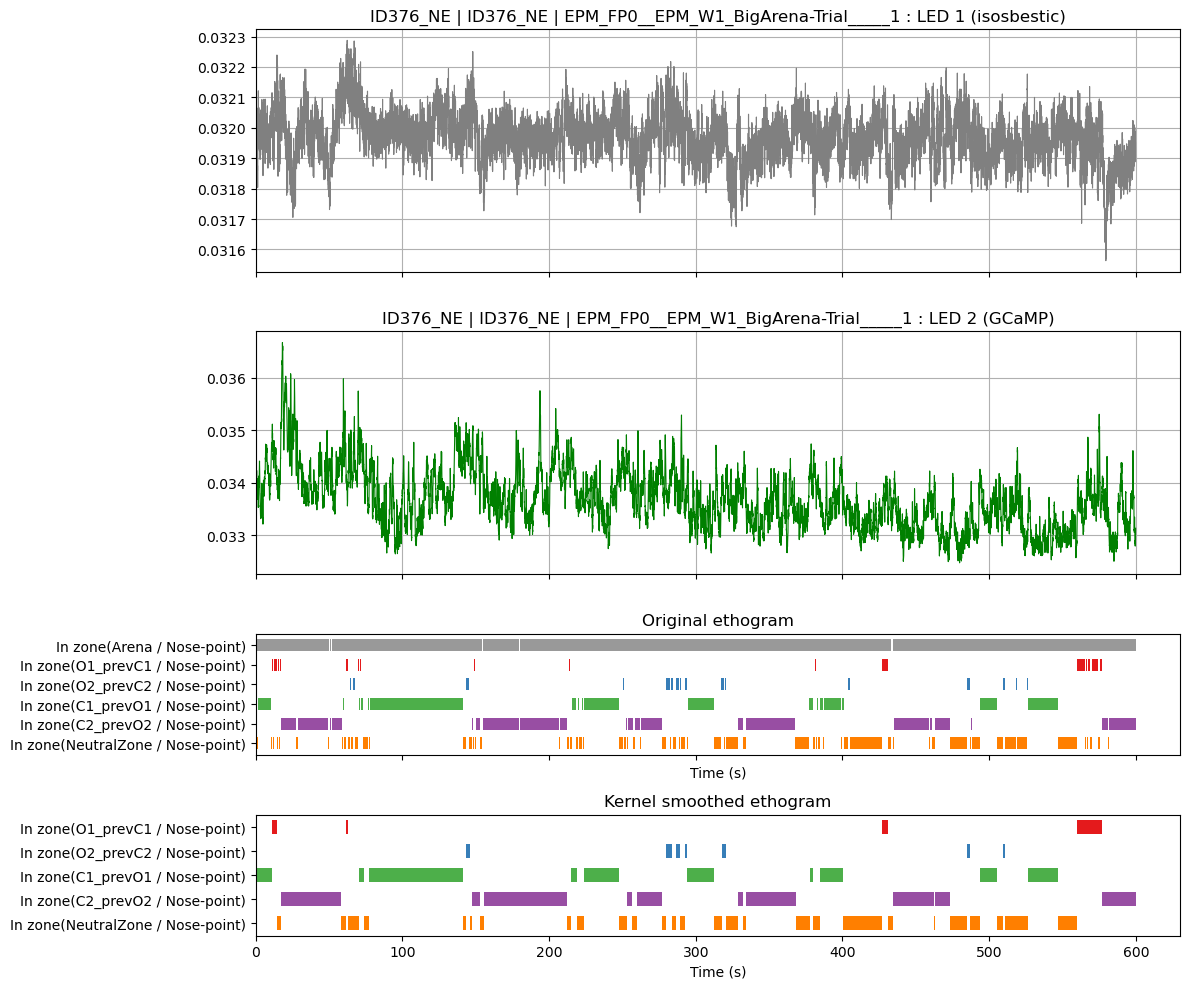

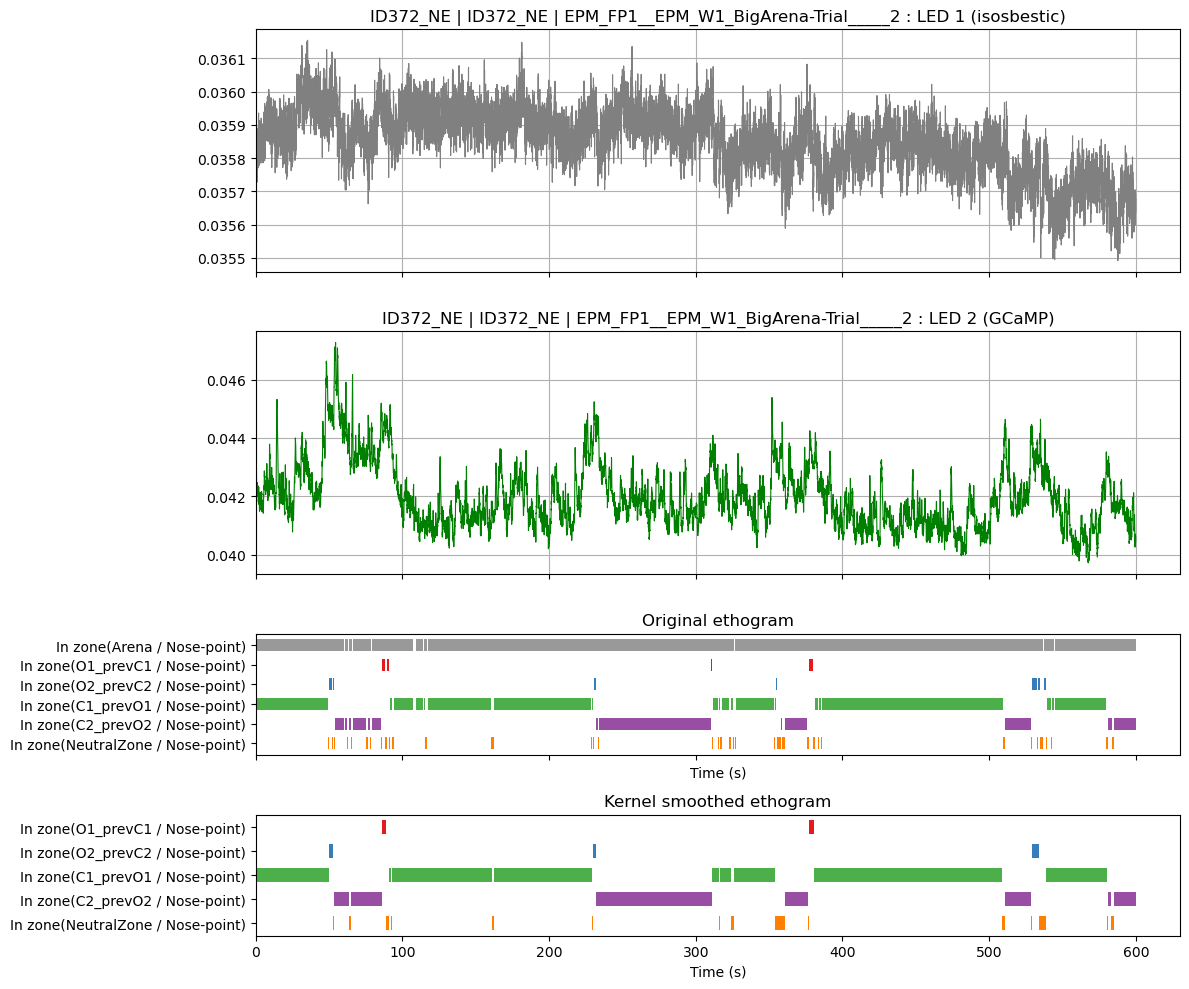

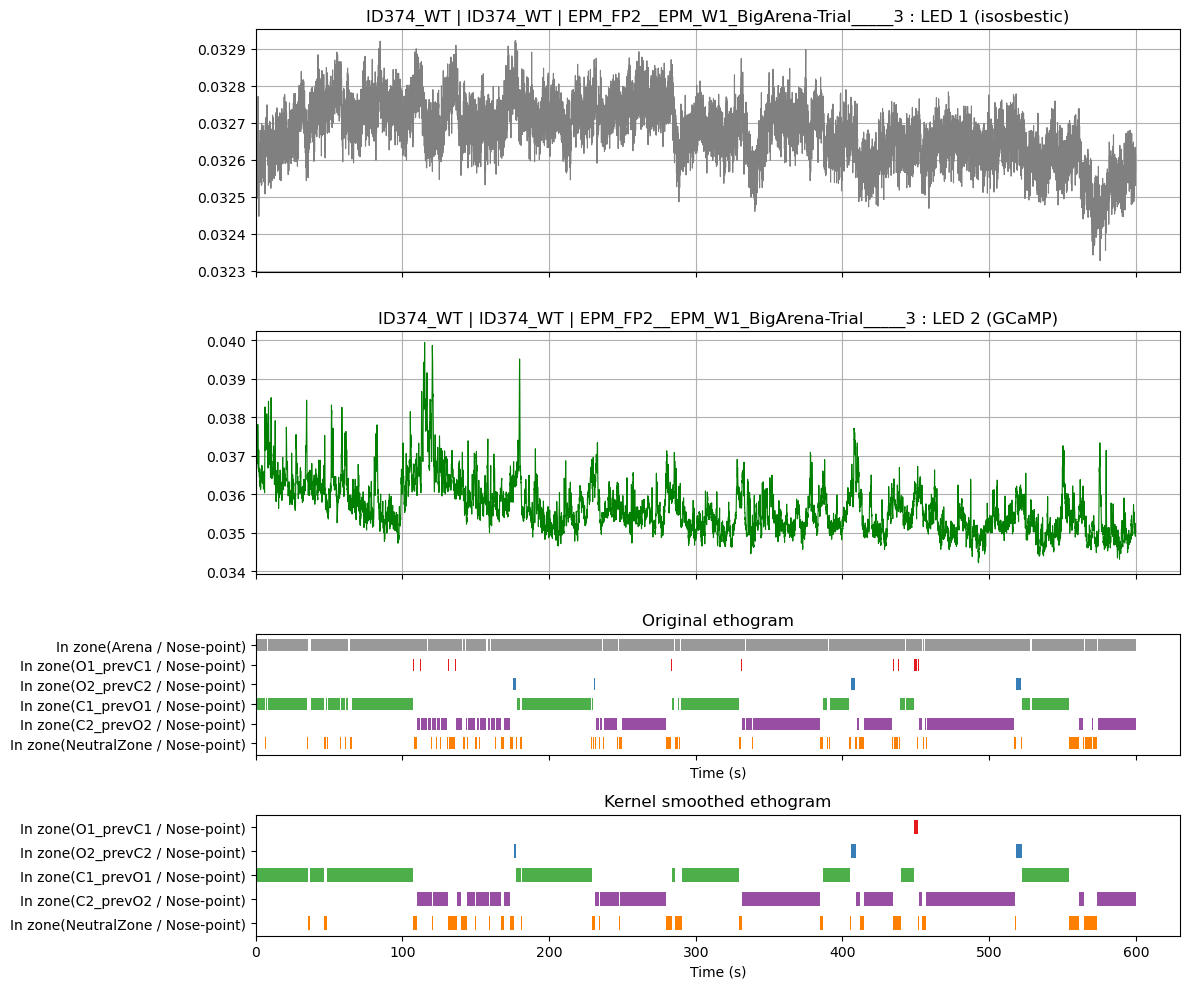

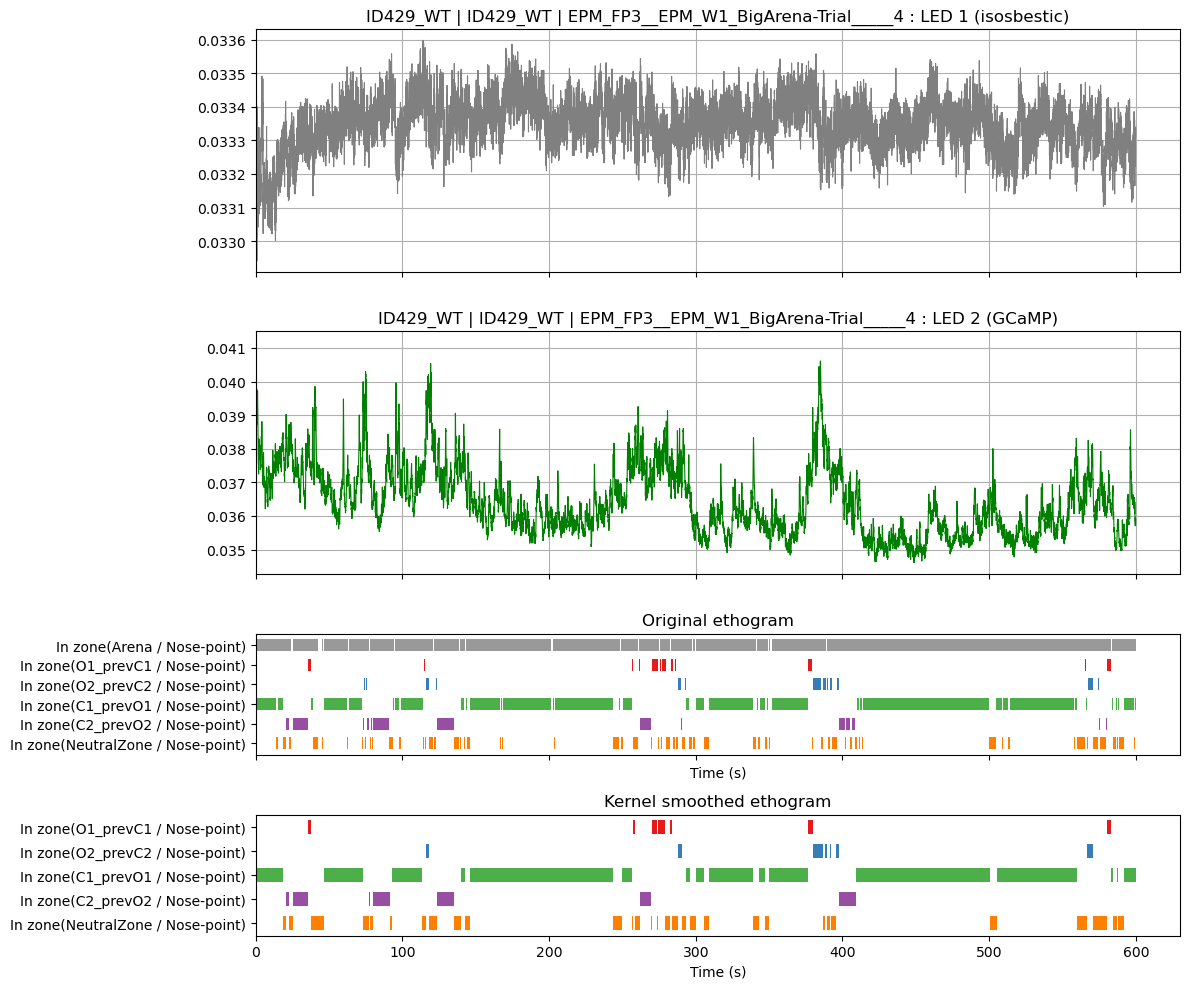

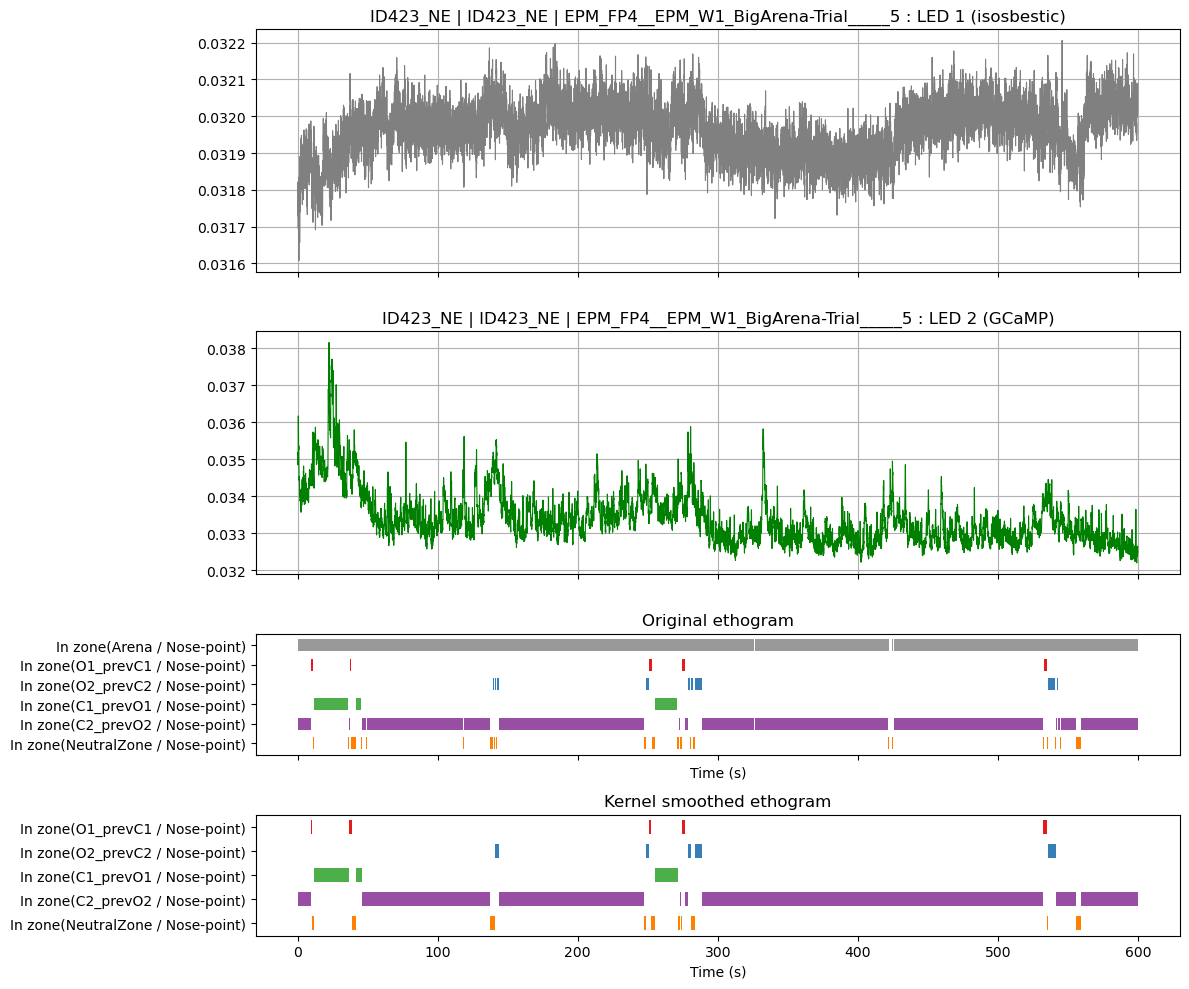

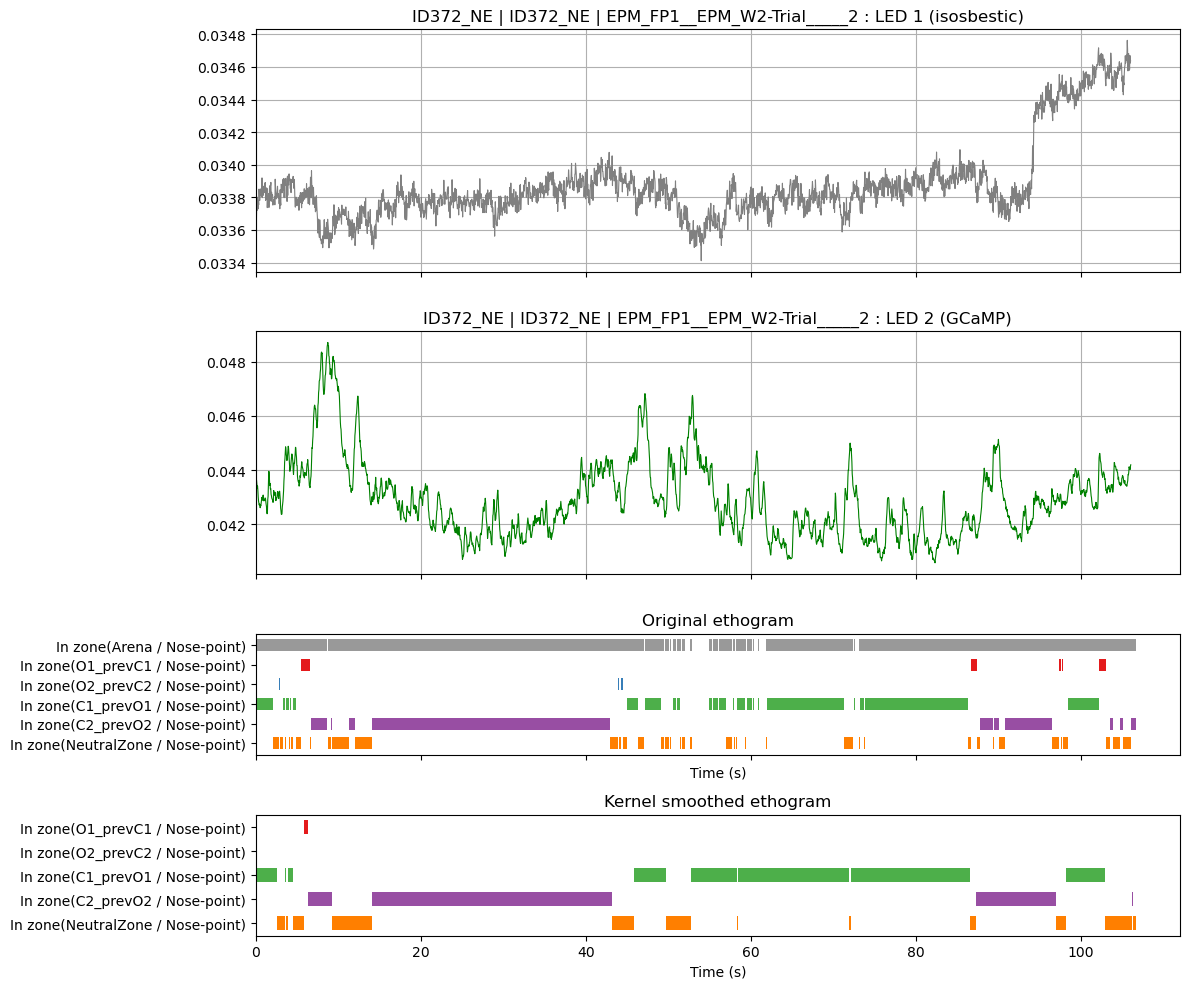

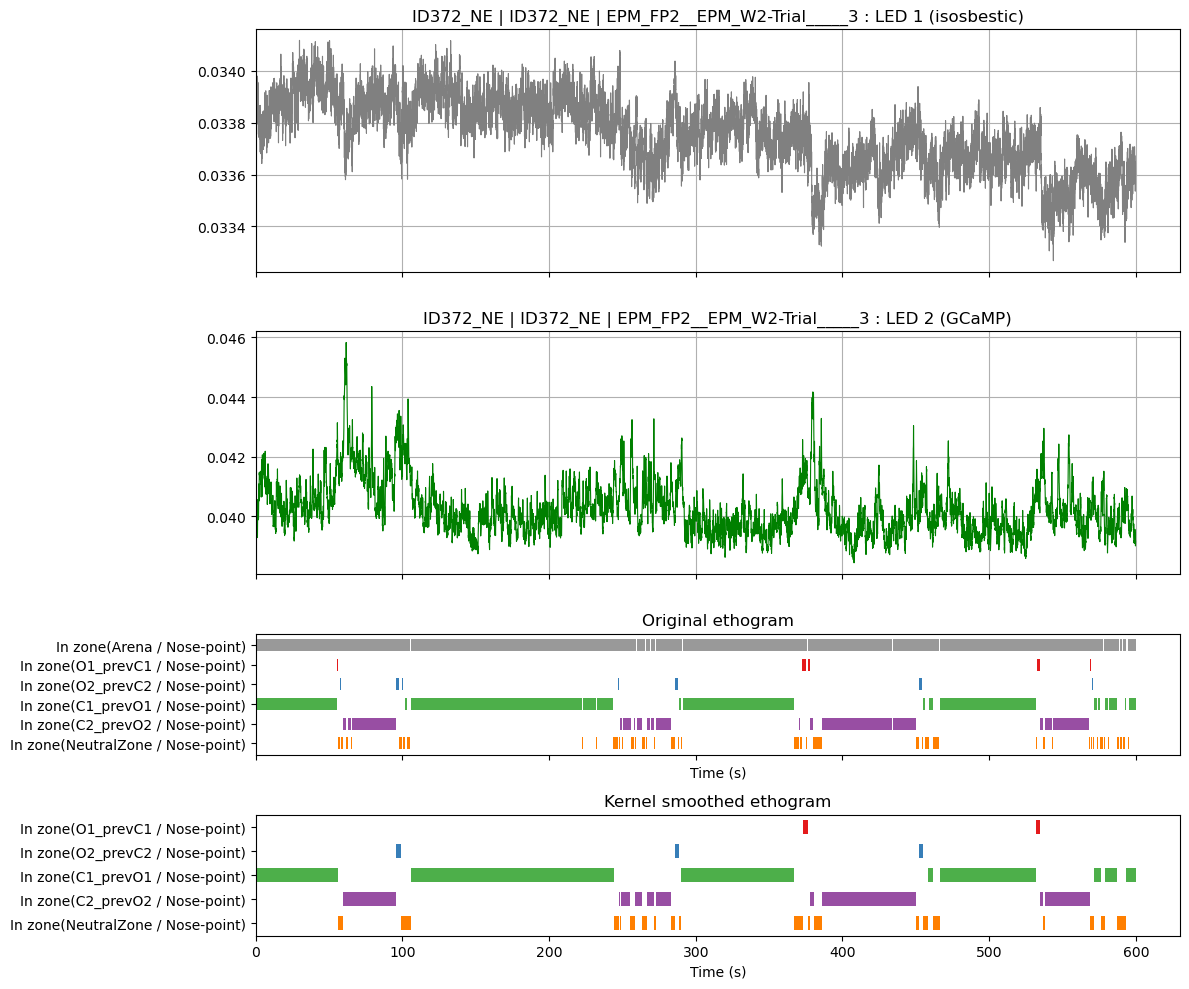

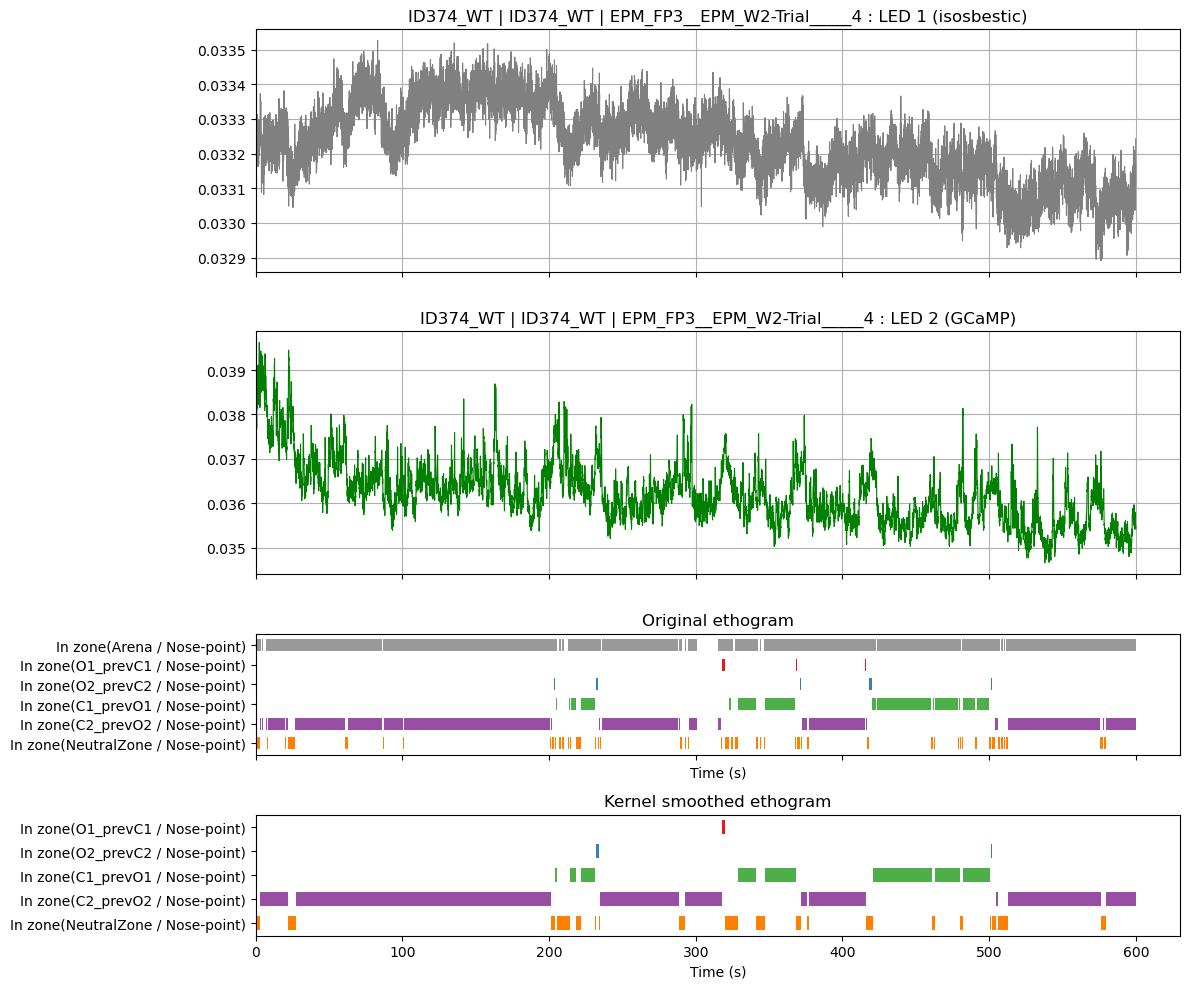

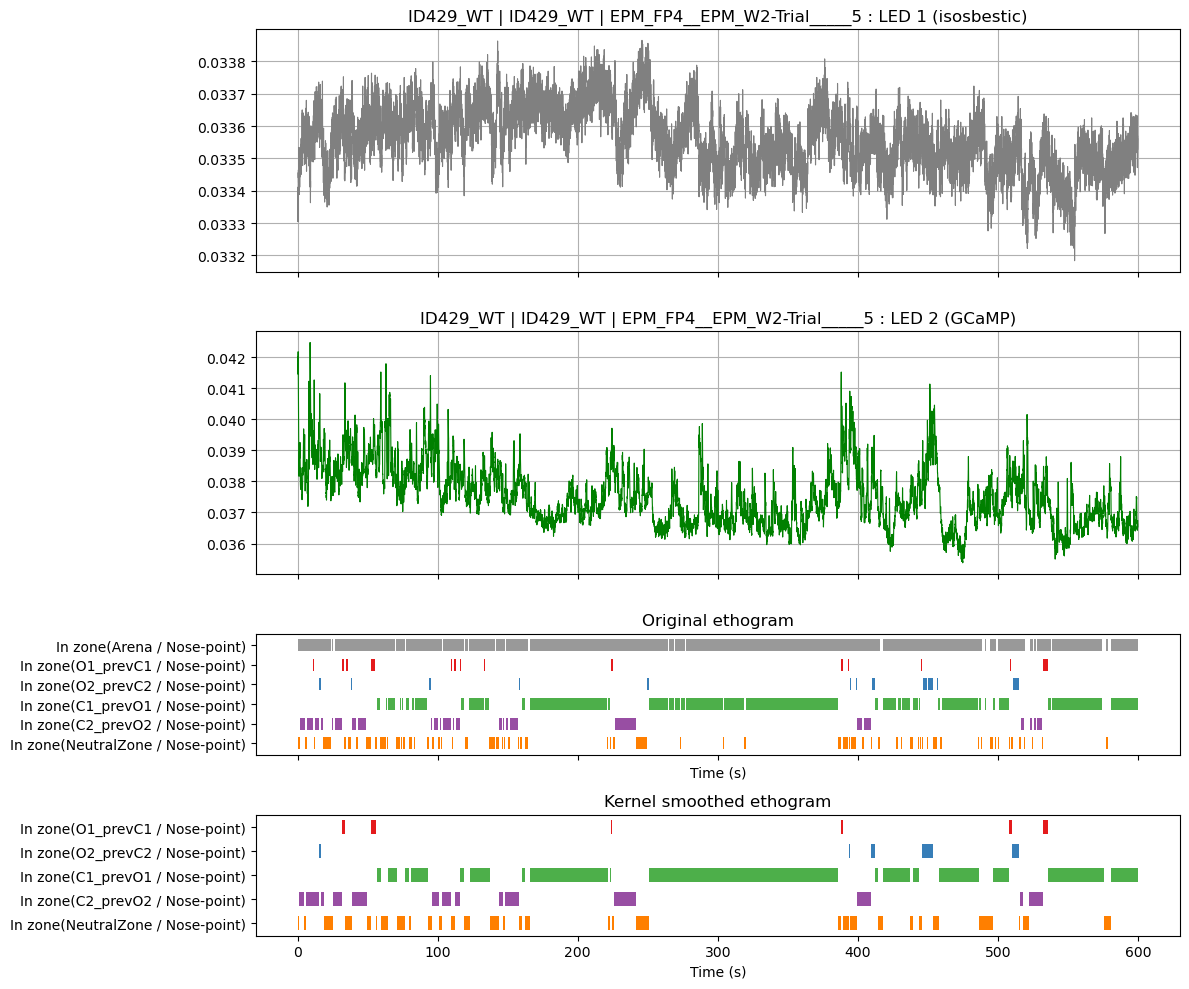

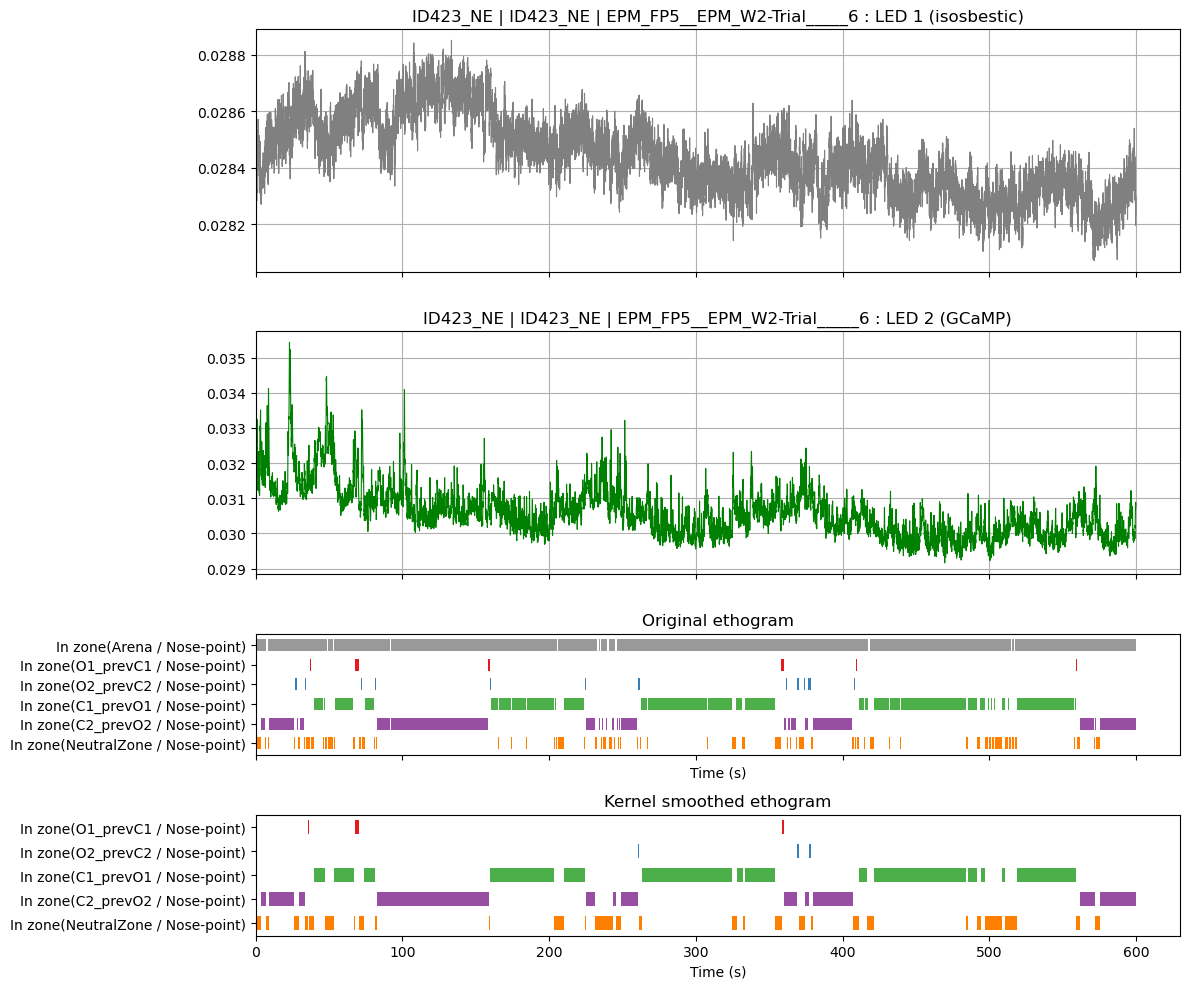

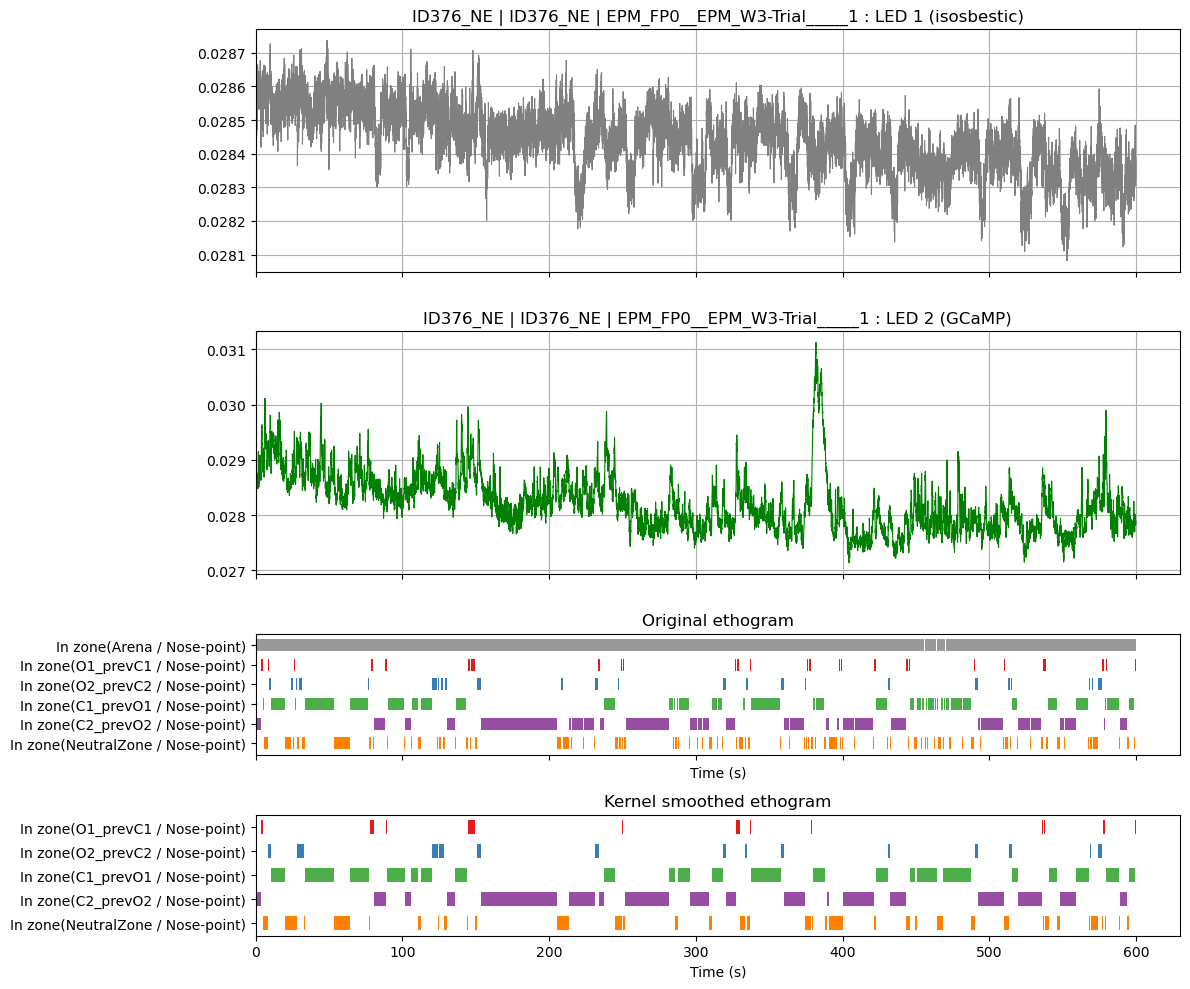

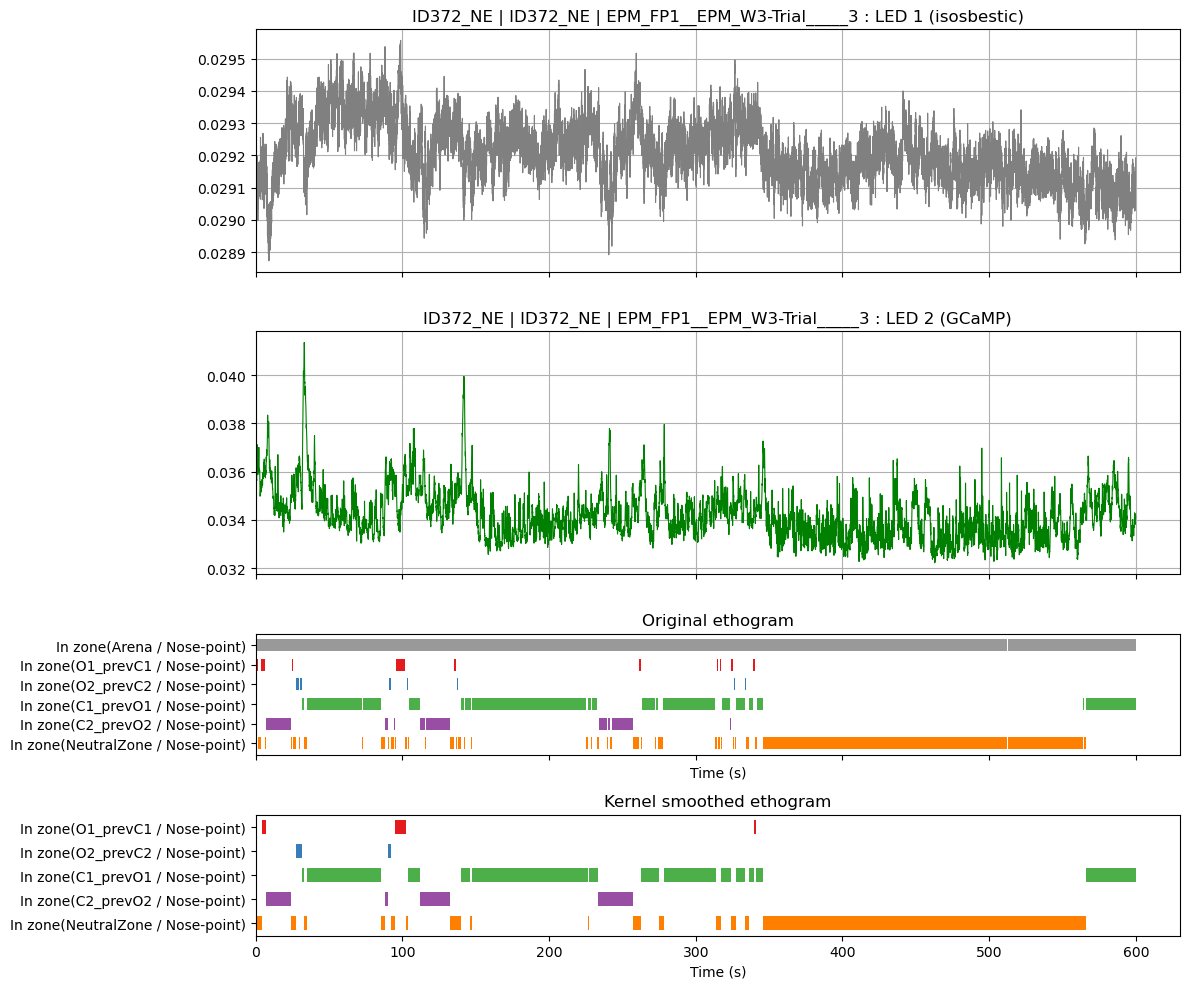

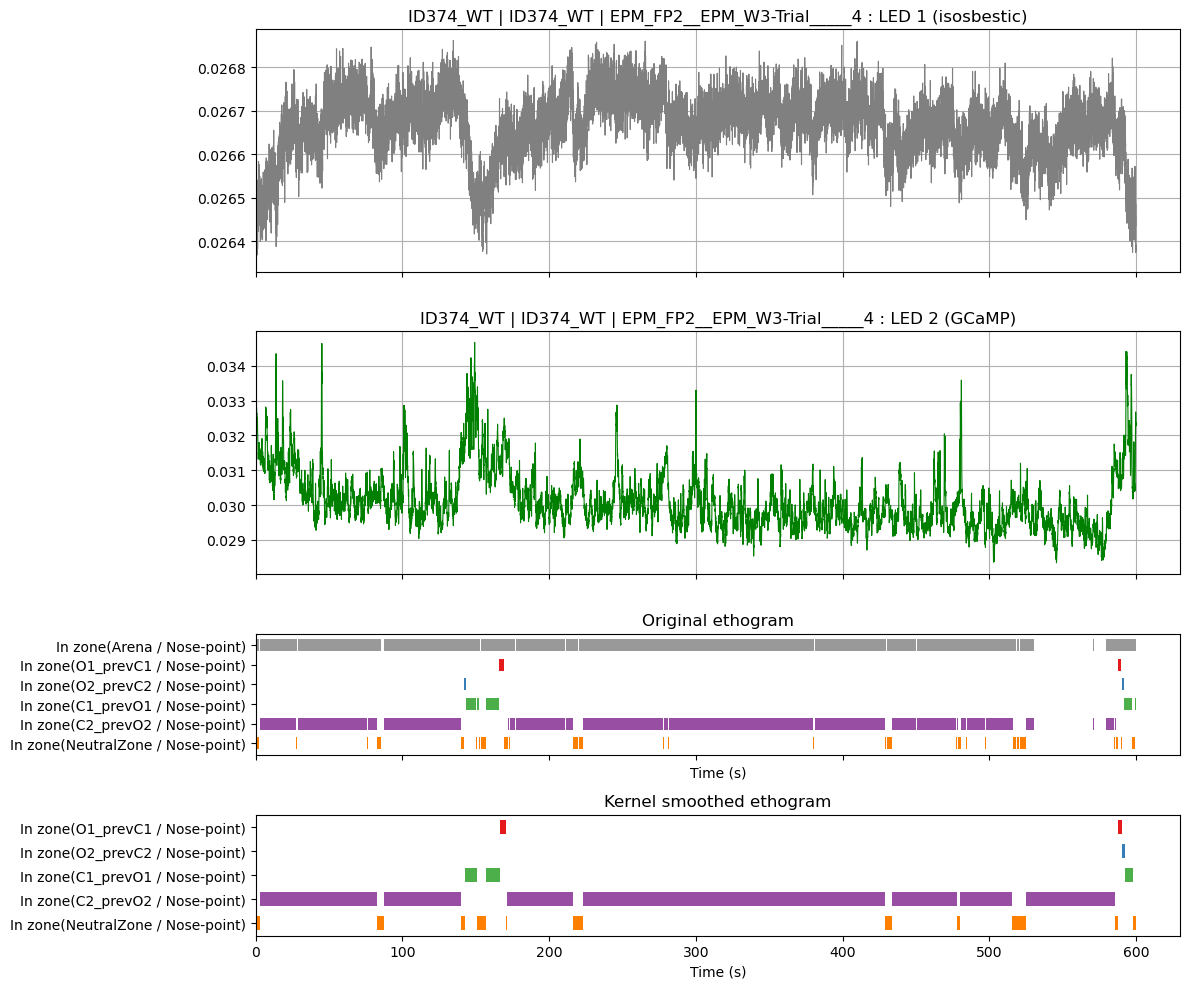

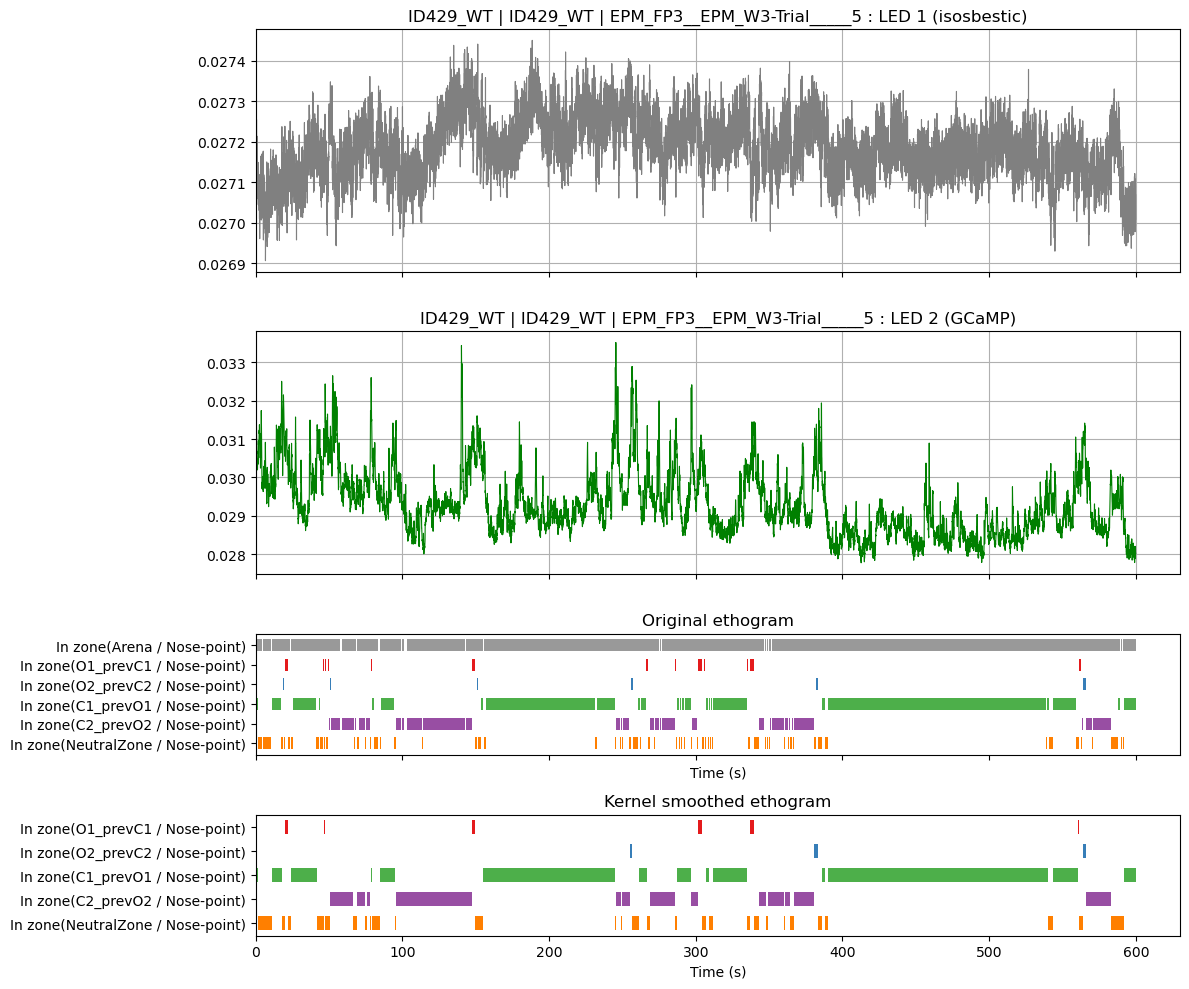

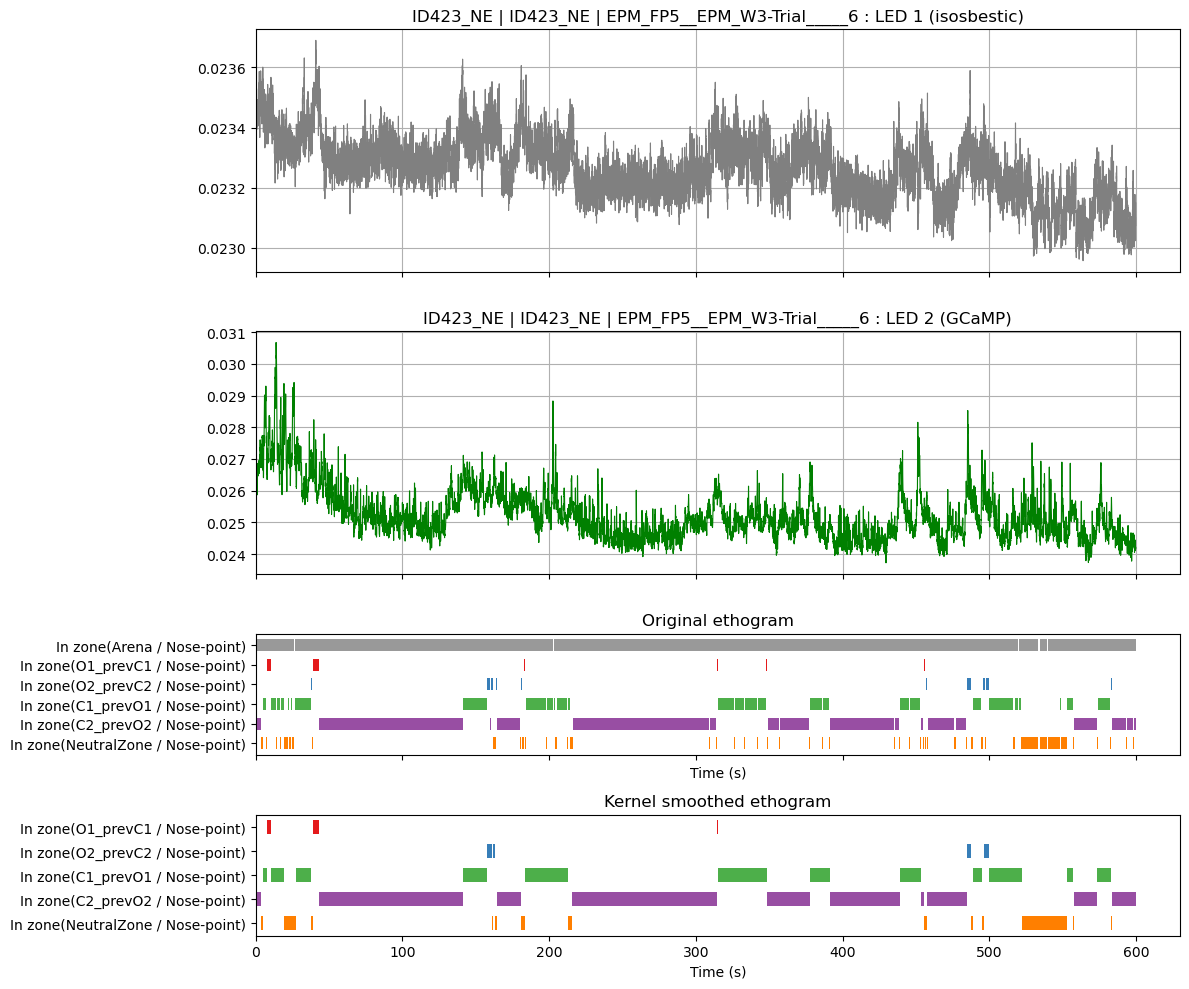

In [56]:
# ==========================================================
# Apply smoothing_kernel and plot kernel-smoothed ethograms for all trials
# ==========================================================

for trial_key, trial_data in fp_traces.items():
    try:
        # Extract FP traces and timeline
        iso_df = trial_data["iso"]
        gcamp_df = trial_data["gcamp"]
        timeline = trial_data["timeline"]
        mouse_label = f"ID{trial_data['mouse_id']}" + (f"_{trial_data['genotype']}" if trial_data['genotype'] else "")
        fp_id = trial_key.split("__")[1]
        trial_stub = "__".join(trial_key.split("__")[2:])

        # # Filter out arena zone before smoothing
        # timeline_filter = timeline[timeline['Behavior'] != 'In zone(Arena / Nose-point)'] \
        #                   .sort_values('Start_time_s')

        # # Apply your original smoothing kernel
        # timeline_kernel_labels = smoothing_kernel(timeline_filter, grainularity=0.1, kernel_size=20)
        # Filter out arena zone before smoothing
        timeline_filter = timeline[
            ~timeline['Behavior'].str.contains('Arena / Nose-point', case=False)
        ].sort_values('Start_time_s')

        # Apply your original smoothing kernel
        timeline_kernel_labels = smoothing_kernel(timeline_filter, grainularity=0.1, kernel_size=20)


        # Plot
        fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True,
                                 gridspec_kw={"height_ratios": [2, 2, 1, 1]})

        # --- FP traces ---
        iso_col = [c for c in iso_df.columns if c != "Time_video"][0]    # dynamically get numeric column
        gcamp_col = [c for c in gcamp_df.columns if c != "Time_video"][0]

        axes[0].plot(iso_df["Time_video"], iso_df[iso_col], linewidth=0.8, color="gray")
        axes[0].set_title(f"{mouse_label} | {fp_id} | {trial_stub} : LED 1 (isosbestic)")
        axes[0].grid(True)

        axes[1].plot(gcamp_df["Time_video"], gcamp_df[gcamp_col], linewidth=0.8, color="green")
        axes[1].set_title(f"{mouse_label} | {fp_id} | {trial_stub} : LED 2 (GCaMP)")
        axes[1].grid(True)

        # --- Original ethogram ---
        beh_cols_orig = trial_data["beh_cols"]
        for i, beh in enumerate(beh_cols_orig):
            color = _guess_zone_color(beh)
            subset = timeline[timeline["Behavior"] == beh]
            for _, row in subset.iterrows():
                axes[2].barh(i, row["Duration_s"], left=row["Start_time_s"], height=0.6, color=color)

        axes[2].set_yticks(range(len(beh_cols_orig)))
        axes[2].set_yticklabels(beh_cols_orig)
        axes[2].invert_yaxis()
        axes[2].set_xlabel("Time (s)")
        axes[2].set_title("Original ethogram")

        # --- Kernel-smoothed ethogram ---
        # beh_cols_clean = [
        #     'In zone(O1_prevC1 / Nose-point)',
        #     'In zone(O2_prevC2 / Nose-point)',
        #     'In zone(C1_prevO1 / Nose-point)',
        #     'In zone(C2_prevO2 / Nose-point)',
        #     'In zone(NeutralZone / Nose-point)'
        # ]
        # for i, beh in enumerate(beh_cols_clean):
        #     color = _guess_zone_color(beh)
        #     subset = timeline_kernel_labels[timeline_kernel_labels["Behavior"] == beh]
        #     for _, row in subset.iterrows():
        #         axes[3].barh(i, row["Duration_s"], left=row["Start_time_s"], height=0.6, color=color)

        # axes[3].set_yticks(range(len(beh_cols_clean)))
        # axes[3].set_yticklabels(beh_cols_clean)
        # axes[3].invert_yaxis()
        # axes[3].set_xlabel("Time (s)")
        # axes[3].set_title("Kernel smoothed ethogram")



        # # --- Kernel-smoothed ethogram ---
        # beh_cols_clean = timeline_kernel_labels["Behavior"].unique()  # dynamically get labels
        # for i, beh in enumerate(beh_cols_clean):
        #     color = _guess_zone_color(beh)
        #     subset = timeline_kernel_labels[timeline_kernel_labels["Behavior"] == beh]
        #     for _, row in subset.iterrows():
        #         axes[3].barh(i, row["Duration_s"], left=row["Start_time_s"], height=0.6, color=color)

        # axes[3].set_yticks(range(len(beh_cols_clean)))
        # axes[3].set_yticklabels(beh_cols_clean)
        # axes[3].invert_yaxis()
        # axes[3].set_xlabel("Time (s)")
        # axes[3].set_title("Kernel smoothed ethogram")
        # --- Kernel-smoothed ethogram ---
        beh_cols_clean = [b for b in beh_cols_orig if 'Arena / Nose-point' not in b]  # same order as original, arena removed
        for i, beh in enumerate(beh_cols_clean):
            color = _guess_zone_color(beh)
            subset = timeline_kernel_labels[timeline_kernel_labels["Behavior"] == beh]
            for _, row in subset.iterrows():
                axes[3].barh(i, row["Duration_s"], left=row["Start_time_s"], height=0.6, color=color)

        axes[3].set_yticks(range(len(beh_cols_clean)))
        axes[3].set_yticklabels(beh_cols_clean)
        axes[3].invert_yaxis()
        axes[3].set_xlabel("Time (s)")
        axes[3].set_title("Kernel smoothed ethogram")



        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"[WARN] Could not plot trial {trial_key}: {e}")


In [ ]:
# # ==========================================================
# # Coregister ISO + GCaMP after the full EPM loop
# # ==========================================================

# def coregister_iso_gcamp(trial_traces: dict) -> pd.DataFrame:
#     """
#     trial_traces dict must contain:
#         trial_traces["iso"]   -> DataFrame with ['Time_video', '<chan>_iso415']
#         trial_traces["gcamp"] -> DataFrame with ['Time_video', '<chan>_gcamp470']
#     """

#     iso = trial_traces["iso"].copy()
#     gcamp = trial_traces["gcamp"].copy()

#     # Extract signal column names
#     iso_col   = [c for c in iso.columns if c != "Time_video"][0]
#     gcamp_col = [c for c in gcamp.columns if c != "Time_video"][0]

#     # Trim both to common length (safe guard)
#     n = min(len(iso), len(gcamp))
#     iso   = iso.iloc[:n].reset_index(drop=True)
#     gcamp = gcamp.iloc[:n].reset_index(drop=True)

#     # Choose main time vector = the one starting earliest
#     if gcamp["Time_video"].iloc[0] <= iso["Time_video"].iloc[0]:
#         time_main = gcamp["Time_video"].values
#     else:
#         time_main = iso["Time_video"].values

#     aligned = pd.DataFrame({
#         "Time_video": time_main,
#         "iso415":    iso[iso_col].values,
#         "gcamp470":  gcamp[gcamp_col].values
#     })

#     return aligned


# # ----------------------------------------------------------
# # Run coregistration for every trial in fp_traces
# # ----------------------------------------------------------
# coregistered_traces = {}

# for key, traces in fp_traces.items():
#     try:
#         aligned_df = coregister_iso_gcamp(traces)
#         coregistered_traces[key] = aligned_df
#     except Exception as e:
#         print(f"[WARN] Could not coregister {key}: {e}")

# print(f"\nCoregistered {len(coregistered_traces)} trials.")


In [ ]:
# first_key = list(coregistered_traces.keys())[0]
# print(first_key)
# print(coregistered_traces[first_key].head())


# code for manually subtracting iso from gcamp by aligning iso and gcamp to occur at same timepoints (a bit artificial, they do not occur at exactly the same timepoint)

In [ ]:
# ==========================================================
# Coregister ISO and GCaMP traces for all timepoints
# ==========================================================

import pandas as pd

def coregister_iso_gcamp(trial_traces: dict) -> pd.DataFrame:
    """
    trial_traces: dict with keys 'iso' and 'gcamp', each a DataFrame like:
        iso:   ['Time_video', 'G0_iso415']
        gcamp:['Time_video', 'G0_gcamp470']

    Returns one DataFrame with:
        Time_video  (from the channel that starts first)
        iso415
        gcamp470
    """
    iso = trial_traces["iso"].copy()
    gcamp = trial_traces["gcamp"].copy()

    # Get signal column names
    iso_col   = [c for c in iso.columns   if c != "Time_video"][0]
    gcamp_col = [c for c in gcamp.columns if c != "Time_video"][0]

    # Trim to common length just in case
    n = min(len(iso), len(gcamp))
    iso   = iso.iloc[:n].reset_index(drop=True)
    gcamp = gcamp.iloc[:n].reset_index(drop=True)

    # Decide which channel is "main" based on starting time
    if gcamp["Time_video"].iloc[0] <= iso["Time_video"].iloc[0]:
        # gcamp starts first → use its time
        time_main = gcamp["Time_video"].values
    else:
        # iso starts first → use its time
        time_main = iso["Time_video"].values

    aligned = pd.DataFrame({
        "Time_video": time_main,
        "iso415": iso[iso_col].values,
        "gcamp470": gcamp[gcamp_col].values,
    })

    return aligned

# -------------------------------------------------
# Apply coregistration to all trials in fp_traces
# -------------------------------------------------

coregistered_traces = {}  # store results per trial

for tp in timepoints:
    # Filter keys for this timepoint
    tp_keys = [k for k in fp_traces.keys() if k.startswith(f"{tp}__")]
    for k in tp_keys:
        try:
            aligned_df = coregister_iso_gcamp(fp_traces[k])
            coregistered_traces[k] = aligned_df
        except Exception as e:
            print(f"[WARN] Could not coregister {k}: {e}")

# Example access:


In [ ]:
# Show the first key
first_key = list(coregistered_traces.keys())[1]
print("First trial key:", first_key)

# Show the head of the aligned dataframe
print(coregistered_traces[first_key].head())


# apply zero-phase moving window - not using subtracted data

After extraction of the data, a zero-phase moving average linear digital filter is applied backwards and forwards to both the channels to reduce high frequency noise without time-shifting. The standard window for the moving filter is 100 data points i GuPPy, but can be adjusted by the user when setting input parameters. The window needs to be adjusted depending on the sampling rate of the recorded data. Guidelines are provided in the user guide. The traces resulting after this filtering step will be displayed for the user to inspect before proceeding with analysis.

In [ ]:
import numpy as np
from scipy.signal import filtfilt

def zero_phase_moving_average(signal, window_pts=5):
    """
    GuPPy-style zero-phase moving average.
    """
    signal = np.asarray(signal, dtype=float)

    if window_pts < 1:
        raise ValueError("window_pts must be >= 1")

    kernel = np.ones(window_pts, dtype=float) / window_pts

    filtered = filtfilt(kernel, [1.0], signal, padlen=3 * window_pts)
    return filtered


# ==========================================================
# Apply zero-phase moving average to all aligned trials
# ==========================================================

smoothed_trials = {}

window_pts = 5  # ≈ 4 seconds at 25 Hz alternation

for key, df in coregistered_traces.items():     # FIXED HERE
    try:
        smoothed_df = df.copy()
        smoothed_df["iso415_smooth"]   = zero_phase_moving_average(df["iso415"].values, window_pts)
        smoothed_df["gcamp470_smooth"] = zero_phase_moving_average(df["gcamp470"].values, window_pts)
        smoothed_trials[key] = smoothed_df
    except Exception as e:
        print(f"[WARN] Could not smooth trial {key}: {e}")

# Example output
example_key = list(smoothed_trials.keys())[0]
print(f"Example smoothed trial: {example_key}")
print(smoothed_trials[example_key].head())


In [ ]:
# import numpy as np
# from scipy.signal import filtfilt

# def zero_phase_moving_average(signal, window_pts=5):
#     """
#     GuPPy-style zero-phase moving average.

#     signal: 1D array-like
#     window_pts: length of moving average window in samples.
#                 For your data (~25 Hz), 100 pts ≈ 4 seconds.
#     """
#     signal = np.asarray(signal, dtype=float)

#     if window_pts < 1:
#         raise ValueError("window_pts must be >= 1")

#     # Moving average kernel
#     kernel = np.ones(window_pts, dtype=float) / window_pts

#     # Zero-phase: forward + backward filtering
#     filtered = filtfilt(kernel, [1.0], signal, padlen=3 * window_pts)
#     return filtered

# # ==========================================================
# # Apply zero-phase moving average to all aligned trials
# # ==========================================================

# smoothed_trials = {}

# # window_pts can be adjusted per your data; default is 100
# window_pts = 100

# for key, df in aligned_trials.items():
#     try:
#         smoothed_df = df.copy()
#         smoothed_df["iso415_smooth"]   = zero_phase_moving_average(df["iso415"].values, window_pts)
#         smoothed_df["gcamp470_smooth"] = zero_phase_moving_average(df["gcamp470"].values, window_pts)
#         smoothed_trials[key] = smoothed_df
#     except Exception as e:
#         print(f"[WARN] Could not smooth trial {key}: {e}")

# # Example: check one smoothed trial
# example_key = list(smoothed_trials.keys())[0]
# print(f"Example smoothed trial: {example_key}")
# print(smoothed_trials[example_key].head())


Nice, you found the key bit in their methods. That paragraph is describing what happens on the TDT rig, not in GuPPy itself:
465 nm and 405 nm LEDs … were demodulated using a 4 Hz low-pass frequency filter.
So there are actually two separate filtering stages in their setup:
Hardware / Synapse side (TDT)
LEDs modulated at ~200–330 Hz
Demodulated and low-pass filtered at 4 Hz on the RZ5P
This already strips out the fast carrier and most high-frequency noise
Software side (GuPPy)
GuPPy then adds a zero-phase moving average filter with a user-defined window (default 100 points) on the demodulated streams
The “Window for Moving Average filter” in GuPPy refers to step 2.
How to think about window_pts in terms of your sampling rate
​	
Larger M → lower cutoff → more aggressive smoothing
Smaller M → higher cutoff → lighter smoothing
What did GuPPy likely do in their own rig?
On TDT they say “demodulated using a 4 Hz low-pass filter”. If their demodulated stream was at around 1 kHz (typical for RZ5P), then:

​	
 ≈4.4 Hz
So a 100-point moving average at ~1 kHz naturally gives about a 4 Hz cutoff, which matches their description.
In your case, though, you’re working with already demultiplexed / downsampled FP3002-style traces at ~25 Hz per channel.
What is “appropriate” for 25 Hz per channel?

​	
 
Some example window_pts:
M (window_pts)	f_c (approx)	Smoothed time scale
3	~3.7 Hz	very light smoothing, almost raw
5	~2.2 Hz	light smoothing
11	~1.0 Hz	moderate smoothing over ~1 s
25	~0.44 Hz	strong smoothing over several seconds
75	~0.15 Hz	very slow trend only, kills fast dynamics

Start with window_pts = 5–11
5 points → f_c ≈ 2.2 Hz (light smoothing)
11 points → f_c ≈ 1.0 Hz (moderate smoothing)

In [ ]:
# # ==========================================================
# # Apply zero-phase moving average to all coregistered trials
# # ==========================================================

# smoothed_trials = {}

# # window_pts can be adjusted per your data; default is 100
# window_pts = 5

# for key, df in coregistered_traces.items():   # <-- use coregistered_traces
#     try:
#         smoothed_df = df.copy()
#         smoothed_df["iso415_smooth"]   = zero_phase_moving_average(df["iso415"].values, window_pts)
#         smoothed_df["gcamp470_smooth"] = zero_phase_moving_average(df["gcamp470"].values, window_pts)
#         smoothed_trials[key] = smoothed_df
#     except Exception as e:
#         print(f"[WARN] Could not smooth trial {key}: {e}")

# # Example: check one smoothed trial
# example_key = list(smoothed_trials.keys())[0]
# print(f"Example smoothed trial: {example_key}")
# print(smoothed_trials[example_key].head())


If you want to process ISO and GCaMP separately (without merging/alignment), you can compute filtered traces only or optionally z-score each independently. ∆F/F won’t make sense without alignment, but you can still smooth and analyze each channel.

In [ ]:
# import numpy as np

# dFF_trials = {}

# for key, df in smoothed_trials.items():  # <-- use smoothed_trials
#     df = df.copy()

#     # 1) Take filtered iso (control) and gcamp (signal) traces as numpy arrays
#     x = df["iso415_smooth"].to_numpy()   # control (405)
#     y = df["gcamp470_smooth"].to_numpy() # signal (470)

#     # 2) Mask out NaNs or infs
#     mask = np.isfinite(x) & np.isfinite(y)
#     x_fit = x[mask]
#     y_fit = y[mask]

#     # 3) Least squares linear regression: y ≈ a*x + b
#     if len(x_fit) < 2:
#         print(f"[WARN] Not enough valid points to fit trial {key}")
#         continue
#     a, b = np.polyfit(x_fit, y_fit, 1)

#     # 4) Fitted control trace for all points
#     Y_fit_all = a * x + b

#     # 5) Delta F = signal − fitted control
#     Y_dF_all = y - Y_fit_all

#     # 6) ∆F/F (%) = 100 * (ΔF / fitted control)
#     eps = np.finfo(float).eps  # avoid division by zero
#     dFF = 100.0 * (Y_dF_all / (Y_fit_all + eps))

#     # 7) Store results in DataFrame
#     df["iso_fit"] = Y_fit_all       # fitted baseline
#     df["dFF"]     = dFF             # ∆F/F in percent

#     # 8) Optional: z-score the dF/F
#     mu  = np.nanmean(dFF)
#     sig = np.nanstd(dFF)
#     df["dFF_z"] = (dFF - mu) / sig if sig > 0 else np.zeros_like(dFF)

#     # Update trial in dictionary
#     dFF_trials[key] = df

# # Example: inspect one trial
# example_key = list(dFF_trials.keys())[0]
# print(f"Example dF/F processed trial: {example_key}")
# print(dFF_trials[example_key].head())


what you’re plotting is not the regression line in 2D space, but the 405 time-series passed through the regression model.

In [ ]:
import numpy as np

preproc_trials = {}

for key, df in smoothed_trials.items():
    df = df.copy()

    # Take smoothed iso (control) and gcamp (signal)
    x = df["iso415_smooth"].to_numpy()
    y = df["gcamp470_smooth"].to_numpy()

    # Mask invalid values
    mask = np.isfinite(x) & np.isfinite(y)
    x_fit = x[mask]
    y_fit = y[mask]

    if len(x_fit) < 2:
        print(f"[WARN] Not enough valid points for trial {key}")
        continue

    # Linear regression: y ≈ a*x + b
    a, b = np.polyfit(x_fit, y_fit, 1)

    # Fitted baseline
    Y_fit_all = a * x + b

    # Delta F
    Y_dF_all = y - Y_fit_all

    # ∆F/F (%)
    eps = np.finfo(float).eps
    dFF = 100.0 * (Y_dF_all / (Y_fit_all + eps))

    # z-scored ∆F/F
    mu  = np.nanmean(dFF)
    sig = np.nanstd(dFF)
    dFF_z = (dFF - mu)/sig if sig > 0 else np.zeros_like(dFF)

    # Store in DataFrame
    df["iso_fit"] = Y_fit_all
    df["dFF"] = dFF
    df["dFF_z"] = dFF_z

    preproc_trials[key] = df


In [ ]:
import matplotlib.pyplot as plt

def plot_preproc_trial(df, key, save_dir=None):
    """
    Plot:
        1) ISO smoothed
        2) GCaMP smoothed
        3) Fitted baseline
        4) dF/F (%)

    df must contain:
        Time_video
        iso415_smooth
        gcamp470_smooth
        iso_fit
        dFF
    """
    time = df["Time_video"].values

    iso  = df["iso415_smooth"].values
    gcamp = df["gcamp470_smooth"].values
    baseline = df["iso_fit"].values
    dFF = df["dFF"].values

    fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

    # 1) ISO 415
    axes[0].plot(time, iso, color="gray", linewidth=1)
    axes[0].set_title(f"{key} — ISO 415 smoothed")
    axes[0].set_ylabel("Signal")

    # 2) GCaMP 470
    axes[1].plot(time, gcamp, color="green", linewidth=1)
    axes[1].set_title("GCaMP 470 smoothed")
    axes[1].set_ylabel("Signal")

    # 3) Baseline fit vs GCaMP
    axes[2].plot(time, gcamp, color="green", linewidth=0.8, label="GCaMP")
    axes[2].plot(time, baseline, color="black", linewidth=0.8, linestyle="--",
                 label="Fitted baseline")
    axes[2].set_title("GCaMP with fitted baseline")
    axes[2].legend(loc="upper right")
    axes[2].set_ylabel("Value")

    # 4) dF/F
    axes[3].plot(time, dFF, color="purple", linewidth=0.8)
    axes[3].set_title("dF/F (%)")
    axes[3].set_xlabel("Time (s)")
    axes[3].set_ylabel("%")

    plt.tight_layout()

    # Save or show
    if save_dir is not None:
        out = save_dir / f"{key}_preproc.png"
        plt.savefig(out, dpi=200)
        plt.close()
    else:
        plt.show()


In [ ]:
# Plot preprocessed trials with fitted baseline and dF/F
for key in preproc_trials.keys():  # <-- use preproc_trials, not smoothed_trials
    try:
        plot_preproc_trial(preproc_trials[key], key)
    except Exception as e:
        print(f"[WARN] Could not plot {key}: {e}")


# Putting together corrections to ethovision ethogram and FP preprocessed traces

In [ ]:
def assign_behavior_to_fp(fp_df, behavior_timeline):
    """
    Assign a behavior label to each FP time point based on the kernel-smoothed timeline.

    Args:
        fp_df: DataFrame with 'Time_video' column
        behavior_timeline: DataFrame with 'Behavior', 'Start_time_s', 'End_time_s'

    Returns:
        fp_df: copy of input with new column 'Behavior'
    """
    fp_df = fp_df.copy()
    fp_df['Behavior'] = 'Unknown'  # default

    for _, row in behavior_timeline.iterrows():
        mask = (fp_df['Time_video'] >= row['Start_time_s']) & (fp_df['Time_video'] < row['End_time_s'])
        fp_df.loc[mask, 'Behavior'] = row['Behavior']

    return fp_df

trial_key = list(preproc_trials.keys())[0]

fp_with_behavior = assign_behavior_to_fp(preproc_trials[trial_key], timeline_kernel_labels)
fp_with_behavior.head()

combined_trials = {}

for key in preproc_trials.keys():
    try:
        # You'll need the corresponding behavior timeline for this trial
        # For now, if only one timeline exists, reuse it:
        combined_trials[key] = assign_behavior_to_fp(preproc_trials[key], timeline_kernel_labels)
    except Exception as e:
        print(f"[WARN] Could not combine trial {key}: {e}")



In [ ]:
import matplotlib.pyplot as plt

def plot_fp_with_behavior(fp_df, trial_key, save_dir=None):
    """
    Plot preprocessed FP traces with behavioral labels overlaid.
    
    fp_df: DataFrame containing:
        Time_video, iso415_smooth, gcamp470_smooth, dFF, Behavior
    trial_key: string (for title)
    save_dir: Path (optional) to save figure
    
    """
    time = fp_df["Time_video"].values
    iso = fp_df["iso415_smooth"].values
    gcamp = fp_df["gcamp470_smooth"].values
    dFF = fp_df["dFF"].values
    behavior = fp_df["Behavior"].values
    
    # Get unique behaviors and assign colors
    beh_unique = list(fp_df["Behavior"].unique())
    color_map = {beh: _guess_zone_color(beh) for beh in beh_unique}
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True,
                             gridspec_kw={"height_ratios": [2, 2, 1]})
    
    # --- FP Traces ---
    axes[0].plot(time, iso, color="gray", linewidth=1)
    axes[0].set_title(f"{trial_key} — ISO 415 smoothed")
    axes[0].set_ylabel("Signal")
    
    axes[1].plot(time, gcamp, color="green", linewidth=1)
    axes[1].set_title(f"{trial_key} — GCaMP 470 smoothed")
    axes[1].set_ylabel("Signal")
    
    # --- Delta F/F ---
    axes[2].plot(time, dFF, color="purple", linewidth=1)
    axes[2].set_ylabel("dF/F (%)")
    axes[2].set_xlabel("Time (s)")
    
    # --- Overlay behavior as colored bars at bottom of dFF plot ---
    y_min, y_max = axes[2].get_ylim()
    bar_height = (y_max - y_min) * 0.05  # small height at bottom
    for beh in beh_unique:
        mask = behavior == beh
        if mask.any():
            # Find contiguous segments
            times = time[mask]
            starts = [times[0]]
            ends = []
            for i in range(1, len(times)):
                if times[i] - times[i-1] > 1.5 * np.median(np.diff(times)):  # gap indicates new segment
                    ends.append(times[i-1])
                    starts.append(times[i])
            ends.append(times[-1])
            for s, e in zip(starts, ends):
                axes[2].barh(y_min + bar_height/2, width=e-s, left=s, height=bar_height,
                             color=color_map[beh], alpha=0.7)
    
    plt.tight_layout()
    
    if save_dir is not None:
        out = save_dir / f"{trial_key}_fp_behavior.png"
        plt.savefig(out, dpi=200)
        plt.close()
    else:
        plt.show()


In [ ]:
trial_key = list(combined_trials.keys())[0]
plot_fp_with_behavior(combined_trials[trial_key], trial_key)


# CORRECTIONS TO ETHOVISION ETHOGRAM
I want to look at the ethovision behavioural data. Right now even if the animal quickly 'transitions' between a phase via the center points quickly jumping back and forth between zones, but the animal not actually fully moving - I want to account for those transitions. if the point transitions to another zone for less than 1 second, take that time spent in the given area, and change it to the previous area where the mouse spent more than 1 second. plot the new and old ethogram above and below one another for each mouse

# PERI EVENT PLOTS CORRECTED SIGNAL


In [ ]:
# # ==========================================================
# # RAW 470 PERI-EVENT PLOTS (no correction)
# # Detects entries into C1, C2, O1, O2, Neutral zones
# # ==========================================================
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from pathlib import Path

# # ---------- PARAMETERS ----------
# pre_s      = 2.0    # seconds before event
# post_s     = 4.0    # seconds after event
# min_stay_s = 1.0    # must stay ≥ 1 s in zone after entry
# out_root   = main_dir / "Figures" / "PeriEventRaw"
# out_root.mkdir(parents=True, exist_ok=True)

# # ---------- MAIN LOOP (dFF version) ----------
# relax_edges = False
# save_empty_plots = True
# global_summary = []

# trial_keys = list(preproc_trials.keys())  # preproc_trials from dFF pipeline

# for trial_key in trial_keys:
#     try:
#         fp_id, trial_stub = trial_key.split("__", 1)
#         df_dff = preproc_trials[trial_key]

#         time_vec = np.asarray(df_dff["Time_video"], dtype=float).ravel()
#         dff_vec  = np.asarray(df_dff["dFF"], dtype=float).ravel()
#         if time_vec.size < 3 or dff_vec.size < 3:
#             print(f"[WARN] {trial_key}: not enough samples; skipping")
#             continue
#         fps_eff = 1/np.nanmean(np.diff(time_vec))

#         # EthoVision
#         eth_path = sorted(export_dir.glob(f"Raw data-*{trial_stub}*.xlsx"))[0]
#         eth, matched_cols = _load_ethovision_sheet_with_targets(eth_path, target_zone_labels, video_fps)
#         if not matched_cols:
#             print(f"[WARN] {trial_key}: no zone columns found"); continue
#         colmap = _zone_column_map(matched_cols)

#         mouse_dir = out_root / fp_id
#         mouse_had_any = False

#         for zone_key in ["C1","C2","O1","O2","Neutral"]:
#             status = {"mouse": fp_id, "trial": trial_stub, "zone": zone_key}
#             if zone_key not in colmap:
#                 status |= {"rises":0,"pass_stay":0,"within_window":0,"edge_dropped":0,"note":"no_column"}
#                 global_summary.append(status)
#                 if save_empty_plots: _plot_empty_stub(fp_id, zone_key, fps_eff, mouse_dir, note="No column")
#                 continue

#             arr = _coerce_zone_binary(eth[colmap[zone_key]])
#             rises = int(np.where(np.diff(np.r_[0, arr]) == 1)[0].size)

#             evt_times = _entrance_times(eth, colmap[zone_key], video_fps, min_stay_s)
#             pass_stay = int(evt_times.size)
#             evt_times = np.asarray(evt_times, dtype=float).ravel()

#             if evt_times.size == 0:
#                 if save_empty_plots: _plot_empty_stub(fp_id, zone_key, fps_eff, mouse_dir, note="No qualifying entries")
#                 status |= {"rises":rises,"pass_stay":pass_stay,"within_window":0,"edge_dropped":0,"note":"no_events"}
#                 global_summary.append(status)
#                 continue

#             ERF, within, edge_dropped = _segments_raw_debug(
#                 time_vec=time_vec, signal_vec=dff_vec, evt_times=evt_times,
#                 pre_s=pre_s, post_s=post_s, fps=fps_eff
#             )

#             status |= {"rises":rises,"pass_stay":pass_stay,"within_window":within,"edge_dropped":edge_dropped,"note":""}
#             global_summary.append(status)

#             if ERF.size > 0:
#                 _plot_peri_raw(fp_id, zone_key, ERF, fps_eff, mouse_dir)
#                 mouse_had_any = True
#             elif save_empty_plots:
#                 _plot_empty_stub(fp_id, zone_key, fps_eff, mouse_dir, note="No qualifying entries")

#         if mouse_had_any:
#             print(f"✅ Peri-event plots (dFF) saved for {trial_key}")
#         else:
#             print(f"[INFO] No zones plotted for {trial_key}")

#     except Exception as e:
#         print(f"[WARN] {trial_key}: {e}")

# # Write summary CSV
# summary_path = out_root / "ALL_mice_event_summary_dFF.csv"
# pd.DataFrame(global_summary).to_csv(summary_path, index=False)
# print(f"\n[INFO] Wrote summary: {summary_path}")


# PERI EVENT PLOTS UNCORRECTED SIGNAL


In [ ]:
# # ==========================================================
# # RAW 470 PERI-EVENT PLOTS (no correction)
# # Detects entries into C1, C2, O1, O2, Neutral zones
# # ==========================================================
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from pathlib import Path

# # ---------- PARAMETERS ----------
# pre_s      = 2.0    # seconds before event
# post_s     = 4.0    # seconds after event
# min_stay_s = 1.0    # must stay ≥ 1 s in zone after entry
# out_root   = main_dir / "Figures" / "PeriEventRaw"
# out_root.mkdir(parents=True, exist_ok=True)

# # ---------- SAFE HELPERS ----------
# def _coerce_zone_binary(series: pd.Series) -> np.ndarray:
#     """Convert EthoVision zone col to 0/1 uint8 (NaNs→0)."""
#     vals = pd.to_numeric(series, errors="coerce").fillna(0.0).to_numpy(dtype=float)
#     return (vals > 0.5).astype(np.uint8)

# def _entrance_times(eth: pd.DataFrame, zone_col: str, fps: float, min_stay_s: float) -> np.ndarray:
#     """Return timestamps for valid zone entries (stay ≥ min_stay_s)."""
#     arr = _coerce_zone_binary(eth[zone_col])
#     dif = np.diff(np.r_[0, arr])           # 1 at 0→1 transitions
#     cand_idx = np.where(dif == 1)[0].astype(int)

#     min_len = int(round(min_stay_s * fps))
#     keep = []
#     for i0 in cand_idx:
#         j = i0
#         while j < arr.size and arr[j] == 1:
#             j += 1
#         if (j - i0) >= min_len:
#             keep.append(i0)

#     # Frame-based time (robust to Time_s NaNs)
#     t = np.arange(len(eth), dtype=float) / float(fps)
#     return t[np.asarray(keep, dtype=int)]

# def _best_match_column(available: list[str], wanted_tokens: list[str]) -> str | None:
#     norm = {c: c.lower().replace(" ", "") for c in available}
#     tokens = [t.lower().replace(" ", "") for t in wanted_tokens]
#     for c, nc in norm.items():
#         if all(tok in nc for tok in tokens):
#             return c
#     return None

# def _zone_column_map(matched_cols: list[str]) -> dict:
#     """Map zone keys (C1,C2,O1,O2,Neutral) → real EthoVision columns."""
#     colmap = {}
#     exact_targets = {
#         "O1": "In zone 2(O1_prevC1 / Center-point)",
#         "O2": "In zone 2(O2_prevC2 / Center-point)",
#         "C1": "In zone 2(C1_prevO1 / Center-point)",
#         "C2": "In zone 2(C2_prevO2 / Center-point)",
#         "Neutral": "In zone 2(NeutralZone / Center-point)",
#     }
#     for k, exact in exact_targets.items():
#         if exact in matched_cols:
#             colmap[k] = exact
#         else:
#             toks = ["inzone2", k.lower()] if k in ("O1","O2","C1","C2") else ["inzone2","neutral"]
#             g = _best_match_column(matched_cols, toks)
#             if g:
#                 colmap[k] = g
#     return colmap

# def _collect_segments_raw(time_vec, signal_vec, evt_times, pre_s, post_s, fps):
#     """Extract raw peri-event signal windows (no baseline)."""
#     pre_n  = int(round(pre_s  * fps))
#     post_n = int(round(post_s * fps))
#     segs = []
#     for ev in evt_times:
#         idx = np.searchsorted(time_vec, ev)
#         if idx >= pre_n and (idx + post_n) < len(signal_vec):
#             segs.append(signal_vec[idx - pre_n : idx + post_n])
#     if not segs:
#         return np.empty((pre_n + post_n, 0))
#     return np.column_stack(segs)

# def _plot_peri_raw(mouse_id, zone_key, ERF, fps, out_dir):
#     """Plot & save raw peri-event traces."""
#     out_dir.mkdir(parents=True, exist_ok=True)
#     pre_n, post_n = int(round(pre_s*fps)), int(round(post_s*fps))
#     t = np.linspace(-pre_s, post_s, pre_n + post_n, endpoint=False)

#     fig, ax = plt.subplots(figsize=(8,4))
#     if ERF.shape[1] > 0:
#         colors = plt.cm.tab10(np.linspace(0,1,ERF.shape[1]))
#         for i,c in enumerate(colors):
#             ax.plot(t, ERF[:,i], color=c, alpha=0.35, lw=1)
#         ax.plot(t, ERF.mean(1), color="k", lw=2.2, label="Mean")
#         ax.legend(frameon=False, loc="upper right")
#     ax.axvline(0, color="k", ls="--", lw=1)
#     ax.set(title=f"{mouse_id}: entry into {zone_key}",
#            xlabel="Time rel. to entry (s)",
#            ylabel="Raw 470 signal (a.u.)")
#     ax.grid(True)
#     plt.tight_layout()
#     out_png = out_dir / f"{mouse_id}__{zone_key}.png"
#     plt.savefig(out_png, dpi=200)
#     plt.close(fig)
#     return out_png




# # ---------- MAIN LOOP (robust, all mice + global summary) ----------
# relax_edges = False      # allow partial windows near edges (pads with NaNs)
# save_empty_plots = True  # save a stub plot even if no events
# global_summary = []      # accumulate across all mice

# def _segments_raw_debug(time_vec, signal_vec, evt_times, pre_s, post_s, fps):
#     pre_n = int(round(pre_s*fps)); post_n = int(round(post_s*fps))
#     n = len(signal_vec)
#     ok_events, dropped_edges = 0, 0
#     segs = []
#     for ev in evt_times:
#         idx = np.searchsorted(time_vec, ev)
#         left = idx - pre_n; right = idx + post_n
#         if left < 0 or right >= n:
#             if relax_edges:
#                 left = max(0, left); right = min(n, right)
#                 seg = signal_vec[left:right].copy()
#                 L = pre_n + post_n
#                 if seg.size < L:
#                     seg = np.concatenate([seg, np.full(L - seg.size, np.nan)])
#                 segs.append(seg); ok_events += 1
#             else:
#                 dropped_edges += 1
#             continue
#         segs.append(signal_vec[left:right]); ok_events += 1
#     ERF = np.column_stack(segs) if segs else np.empty((pre_n + post_n, 0))
#     return ERF, ok_events, dropped_edges

# def _plot_empty_stub(mouse_id, zone_key, fps, out_dir, note="No qualifying entries"):
#     out_dir.mkdir(parents=True, exist_ok=True)
#     pre_n = int(round(pre_s*fps)); post_n = int(round(post_s*fps))
#     t = np.linspace(-pre_s, post_s, pre_n + post_n, endpoint=False)
#     fig, ax = plt.subplots(figsize=(8,4))
#     ax.axvline(0, color="k", ls="--", lw=1)
#     ax.text(0.02, 0.9, note, transform=ax.transAxes)
#     ax.set(title=f"{mouse_id}: entry into {zone_key}",
#            xlabel="Time rel. to entry (s)", ylabel="Raw 470 signal (a.u.)")
#     ax.grid(True)
#     plt.tight_layout()
#     out_png = out_root / mouse_id / f"{mouse_id}__{zone_key}.png"
#     plt.savefig(out_png, dpi=200); plt.close(fig)

# trial_files = sorted(export_dir.glob("Raw data-*.xlsx"))
# print(f"[INFO] Found {len(trial_files)} trials")
# for i_trial, eth_path in enumerate(trial_files, 1):
#     try:
#         fp_id = _read_export_and_get_fp_id(eth_path)
#         print(f"\n--- [{i_trial}/{len(trial_files)}] {eth_path.name} → {fp_id} ---")

#         # FP trim
#         fp_folder = main_dir / fp_id
#         fp_csv, ts_csv = _find_fp_and_timestamp_files(fp_folder, fp_id)
#         fp = pd.read_csv(fp_csv); fp = fp[fp["LedState"].isin([1,2])].copy()
#         ts = pd.read_csv(ts_csv)
#         start, stop = _get_video_window(ts)
#         fp_trim = _trim_fp_to_window(fp, start=start, stop=stop)

#         # LED2 channel/time
#         gmask = fp_trim["LedState"] == 2
#         g_time = fp_trim.loc[gmask,"Time_video"].to_numpy(float)
#         if g_time.size < 3:
#             print("[WARN] LED2 has too few samples; skipping")
#             continue
#         fps_eff = 1/np.mean(np.diff(g_time))
#         chan = "G0" if "G0" in fp_trim.columns else next(
#             c for c in fp_trim.columns
#             if pd.api.types.is_numeric_dtype(fp_trim[c])
#             and c not in {"SystemTimestamp","LedState","Time_video","Time_s","Timestamp"}
#         )
#         raw470 = fp_trim.loc[gmask, chan].to_numpy(float)

#         # EthoVision
#         eth, matched_cols = _load_ethovision_sheet_with_targets(eth_path, target_zone_labels, video_fps)
#         print(f"[INFO] matched_cols: {matched_cols}")
#         if not matched_cols:
#             print("[WARN] No zone cols found"); continue
#         colmap = _zone_column_map(matched_cols)
#         print(f"[INFO] colmap: {colmap}")
#         if not colmap:
#             print("[WARN] Zone mapping failed"); continue

#         mouse_dir = out_root / fp_id
#         mouse_had_any = False

#         for zone_key in ["C1","C2","O1","O2","Neutral"]:
#             status = {"mouse": fp_id, "trial": eth_path.name, "zone": zone_key}
#             if zone_key not in colmap:
#                 print(f"[INFO] {zone_key}: column not present"); 
#                 status |= {"rises":0,"pass_stay":0,"within_window":0,"edge_dropped":0,"note":"no_column"}
#                 global_summary.append(status)
#                 if save_empty_plots: _plot_empty_stub(fp_id, zone_key, fps_eff, mouse_dir)
#                 continue

#             # raw rises
#             arr = _coerce_zone_binary(eth[colmap[zone_key]])
#             rises = int(np.where(np.diff(np.r_[0, arr]) == 1)[0].size)
#             # pass 1s stay
#             idx_keep = _entrance_times(eth, colmap[zone_key], video_fps, min_stay_s)
#             pass_stay = int(idx_keep.size)
#             evt_times = idx_keep  # already timestamps from _entrance_times

#             # segments and edge drops
#             ERF, within, edge_dropped = _segments_raw_debug(
#                 time_vec=g_time, signal_vec=raw470, evt_times=evt_times,
#                 pre_s=pre_s, post_s=post_s, fps=fps_eff
#             )
#             print(f"[{fp_id} {zone_key}] rises={rises}, pass_stay={pass_stay}, "
#                   f"within_window={within}, edge_dropped={edge_dropped}")

#             status |= {"rises":rises, "pass_stay":pass_stay,
#                        "within_window":within, "edge_dropped":edge_dropped,
#                        "note":""}
#             global_summary.append(status)

#             if ERF.size == 0:
#                 if save_empty_plots:
#                     _plot_empty_stub(fp_id, zone_key, fps_eff, mouse_dir,
#                                      note="No qualifying entries")
#                 continue

#             _plot_peri_raw(fp_id, zone_key, ERF, fps_eff, mouse_dir)
#             mouse_had_any = True

#         if mouse_had_any:
#             print(f"✅ Peri-event plots saved in {mouse_dir}")
#         else:
#             print(f"[INFO] No zones plotted for {fp_id} (empty or filtered); stub images may exist")

#     except Exception as e:
#         print(f"[WARN] {eth_path.name}: {e}")

# # Write a single CSV with all mice/zones
# summary_path = out_root / "ALL_mice_event_summary.csv"
# pd.DataFrame(global_summary).to_csv(summary_path, index=False)
# print(f"\n[INFO] Wrote summary: {summary_path}")


In [ ]:
# ==========================================================
# RAW 470 PERI-EVENT PLOTS (EPM)
# ==========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- PARAMETERS ----------
pre_s      = 2.0    # seconds before entry
post_s     = 4.0    # seconds after entry
min_stay_s = 1.0    # must stay ≥1 s in zone to count
fps_eth    = 50.0   # EPM ethovision fps

out_root   = main_dir / "Figures" / "PeriEventRaw"
out_root.mkdir(parents=True, exist_ok=True)

# These MUST match your EPM center-point zone format
target_zone_labels = [
    "In zone 2(O1_prevC1 / Center-point)",
    "In zone 2(O2_prevC2 / Center-point)",
    "In zone 2(C1_prevO1 / Center-point)",
    "In zone 2(C2_prevO2 / Center-point)",
    "In zone 2(NeutralZone / Center-point)"
]


# ---------- HELPERS ----------
def _coerce_zone_binary(series: pd.Series) -> np.ndarray:
    return (pd.to_numeric(series, errors="coerce")
            .fillna(0).to_numpy(dtype=float) > 0.5).astype(np.uint8)


def _entrance_times(eth: pd.DataFrame, zone_col: str, fps: float, min_stay_s: float):
    """Return timestamps for valid zone entries where mouse stays ≥min_stay."""
    arr = _coerce_zone_binary(eth[zone_col])
    rising = np.diff(np.r_[0, arr]) == 1
    candidates = np.where(rising)[0]

    min_len = int(round(min_stay_s * fps))
    keep = []

    for i0 in candidates:
        j = i0
        while j < len(arr) and arr[j] == 1:
            j += 1
        if (j - i0) >= min_len:
            keep.append(i0)

    # Convert index → time
    t = np.arange(len(arr)) / fps
    return t[np.asarray(keep, dtype=int)]


def _best_match_column(available: list[str], tokens: list[str]) -> str | None:
    norm = {c: c.lower().replace(" ", "") for c in available}
    tokens = [t.lower().replace(" ", "") for t in tokens]
    for c, nc in norm.items():
        if all(tok in nc for tok in tokens):
            return c
    return None


def _zone_column_map_for_epm(matched_cols):
    """Map EPM Center-point zones: C1,C2,O1,O2,Neutral."""
    colmap = {}
    targets = {
        "O1": "O1_prevC1",
        "O2": "O2_prevC2",
        "C1": "C1_prevO1",
        "C2": "C2_prevO2",
        "Neutral": "NeutralZone"
    }
    for key, tok in targets.items():
        col = _best_match_column(matched_cols, [tok, "center"])
        if col:
            colmap[key] = col
    return colmap


def _collect_segments(time_vec, signal_vec, evt_times, pre_s, post_s, fps):
    """Collect peri-event windows."""
    pre_n  = int(pre_s * fps)
    post_n = int(post_s * fps)
    segs = []

    for ev in evt_times:
        idx = np.searchsorted(time_vec, ev)
        if idx >= pre_n and idx + post_n < len(signal_vec):
            segs.append(signal_vec[idx-pre_n : idx+post_n])

    if not segs:
        return np.empty((pre_n+post_n, 0))

    return np.column_stack(segs)


def _plot_peri(mouse_id, zone_key, ERF, fps, out_dir):
    out_dir.mkdir(parents=True, exist_ok=True)

    pre_n  = int(pre_s * fps)
    post_n = int(post_s * fps)
    t      = np.linspace(-pre_s, post_s, pre_n + post_n)

    fig, ax = plt.subplots(figsize=(8,4))

    if ERF.shape[1] > 0:
        for i in range(ERF.shape[1]):
            ax.plot(t, ERF[:,i], color="gray", alpha=0.3)
        ax.plot(t, ERF.mean(axis=1), color="k", lw=2)

    ax.axvline(0, color="k", ls="--")
    ax.set(title=f"{mouse_id}: entry → {zone_key}",
           xlabel="Time (s)",
           ylabel="Raw 470")
    ax.grid(True)

    out_png = out_dir / f"{mouse_id}_{zone_key}.png"
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close()
    return out_png


# ==========================================================
# MAIN PERI-EVENT LOOP
# ==========================================================

print("\n[INFO] Starting peri-event extraction...")
eth_export_dir = main_dir / "Preinduction" / "Export files"
trial_files = sorted(eth_export_dir.glob("Raw data-*.xlsx"))

print(f"[INFO] Found {len(trial_files)} trials")

global_summary = []

for eth_path in trial_files:
    try:
        # FIXED: use correct function name
        fp_id, mouse_id = _read_export_and_get_fp_and_mouse_id(eth_path)
        print(f"\n--- Processing {eth_path.name} → Mouse {mouse_id}, FP {fp_id}")

        # Find FP files
        fp_folder = main_dir / "Preinduction" / fp_id
        fp_csv, ts_csv = _find_fp_and_timestamp_files(fp_folder, fp_id)

        fp     = pd.read_csv(fp_csv)
        ts     = pd.read_csv(ts_csv)
        start, stop = _get_video_window(ts)
        fp_trim = _trim_fp_to_window(fp, start, stop)

        # Extract LED2 (GCaMP)
        gmask = fp_trim["LedState"] == 2
        g_time = fp_trim.loc[gmask, "Time_video"].to_numpy(float)
        chan   = next(c for c in fp_trim.columns if c.startswith("G") and c not in ["LedState","Time_video"])
        raw470 = fp_trim.loc[gmask, chan].to_numpy(float)

        # Load EthoVision
        eth, matched_cols = _load_ethovision_sheet_with_targets(eth_path, fps_eth)
        colmap = _zone_column_map_for_epm(matched_cols)

        mouse_dir = out_root / fp_id
        mouse_dir.mkdir(parents=True, exist_ok=True)

        for zone_key, colname in colmap.items():
            evt_times = _entrance_times(eth, colname, fps_eth, min_stay_s)
            ERF = _collect_segments(g_time, raw470, evt_times, pre_s, post_s, fps_eth)

            # save summary row
            global_summary.append({
                "mouse": mouse_id,
                "fp_id": fp_id,
                "zone": zone_key,
                "n_entries": len(evt_times),
                "n_segments": ERF.shape[1]
            })

            # Save plot
            _plot_peri(mouse_id, zone_key, ERF, fps_eth, mouse_dir)

    except Exception as e:
        print(f"[WARN] {eth_path.name}: {e}")

# Save summary
summary_df = pd.DataFrame(global_summary)
summary_path = out_root / "ALL_mice_event_summary.csv"
summary_df.to_csv(summary_path, index=False)

print(f"\n[INFO] Wrote summary → {summary_path}")


In [ ]:
# # ==========================================================
# # PERI-EVENT PLOTS USING PREPROCESSED dF/F FROM preproc_trials
# # ==========================================================
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from pathlib import Path

# # ---------------------------------
# # PARAMETERS
# # ---------------------------------
# pre_s      = 2.0       # seconds before entry
# post_s     = 4.0       # seconds after entry
# min_stay_s = 1.0       # must stay >=1s in zone
# fps_eth    = 50.0      # EPM video framerate

# out_root   = main_dir / "Figures" / "PeriEvent_dFF"
# out_root.mkdir(parents=True, exist_ok=True)

# # EPM center-point zone labels
# target_zone_labels = [
#     "In zone 2(O1_prevC1 / Center-point)",
#     "In zone 2(O2_prevC2 / Center-point)",
#     "In zone 2(C1_prevO1 / Center-point)",
#     "In zone 2(C2_prevO2 / Center-point)",
#     "In zone 2(NeutralZone / Center-point)"
# ]


# # ==========================================================
# # HELPER FUNCTIONS
# # ==========================================================
# def _bin(series):
#     """Convert EthoVision zone column → 0/1."""
#     return (pd.to_numeric(series, errors="coerce")
#             .fillna(0).to_numpy(float) > 0.5).astype(np.uint8)


# def _entrances(eth, colname, fps, min_stay_s):
#     """Detect entries followed by staying >= required time."""
#     arr = _bin(eth[colname])
#     rising = np.diff(np.r_[0, arr]) == 1
#     idx = np.where(rising)[0]

#     min_len = int(min_stay_s * fps)
#     keep = []

#     for i0 in idx:
#         j = i0
#         while j < len(arr) and arr[j] == 1:
#             j += 1
#         if (j - i0) >= min_len:
#             keep.append(i0)

#     t = np.arange(len(arr)) / fps
#     return t[keep]


# def _zone_map(matched_cols):
#     """Map canonical zone keys → actual EthoVision columns."""
#     zones = {
#         "O1": "O1_prevC1",
#         "O2": "O2_prevC2",
#         "C1": "C1_prevO1",
#         "C2": "C2_prevO2",
#         "Neutral": "NeutralZone",
#     }
#     colmap = {}
#     for key, tok in zones.items():
#         hits = [c for c in matched_cols if tok in c]
#         if hits:
#             colmap[key] = hits[0]
#     return colmap


# def _extract_segments(time_vec, signal, evt_times, pre_s, post_s):
#     pre_n  = int(pre_s * fps_eth)
#     post_n = int(post_s * fps_eth)

#     segments = []

#     for ev in evt_times:
#         idx = np.searchsorted(time_vec, ev)
#         if idx >= pre_n and idx + post_n < len(signal):
#             seg = signal[idx-pre_n : idx+post_n]
#             segments.append(seg)

#     if not segments:
#         return np.empty((pre_n + post_n, 0))

#     return np.column_stack(segments)


# def _plot_peri(mouse_id, zone_key, ERF, out_dir):
#     out_dir.mkdir(parents=True, exist_ok=True)
#     pre_n  = int(pre_s * fps_eth)
#     post_n = int(post_s * fps_eth)
#     t = np.linspace(-pre_s, post_s, pre_n + post_n)

#     fig, ax = plt.subplots(figsize=(8,4))

#     if ERF.shape[1] > 0:
#         for i in range(ERF.shape[1]):
#             ax.plot(t, ERF[:,i], color="gray", alpha=0.3)

#         ax.plot(t, ERF.mean(axis=1), color="k", lw=2)

#     ax.axvline(0, color="k", ls="--")
#     ax.set(
#         title=f"{mouse_id}: entry → {zone_key}",
#         xlabel="Time (s)",
#         ylabel="dF/F (%)"
#     )
#     ax.grid(True)

#     out_file = out_dir / f"{mouse_id}_{zone_key}.png"
#     plt.tight_layout()
#     plt.savefig(out_file, dpi=200)
#     plt.close()


# # ==========================================================
# # MAIN PERI-EVENT LOOP USING preproc_trials
# # ==========================================================

# print("\n[INFO] Running peri-event extraction on preprocessed dF/F traces...")

# global_summary = []

# # Loop through *each trial* in your preproc dict
# for key, df_pre in preproc_trials.items():

#     # Key format: "W1__ID372_NE__FP123__EPM_W1_Trial_1"
#     timepoint = key.split("__")[0]
#     mouse_id  = key.split("__")[1]

#     # Ethovision file for this trial
#     tp_dir = main_dir / timepoint / "Export files"
#     trial_stub = key.split("__")[-1]      # last part of key
#     eth_file = None

#     for f in tp_dir.glob("Raw data-*.xlsx"):
#         if trial_stub.replace("_", " ") in f.name.replace(" ", ""):
#             eth_file = f
#             break

#     if eth_file is None:
#         print(f"[WARN] EthoVision file not found for {key}")
#         continue

#     # Load EthoVision zones
#     eth, matched_cols = _load_ethovision_sheet_with_targets(eth_file, fps_eth)
#     colmap = _zone_map(matched_cols)

#     # Preprocessed signal
#     signal = df_pre["dFF"].to_numpy(float)
#     time_vec = df_pre["Time_video"].to_numpy(float)

#     mouse_dir = out_root / mouse_id

#     for zone_key, colname in colmap.items():
#         evt_times = _entrances(eth, colname, fps_eth, min_stay_s)
#         ERF = _extract_segments(time_vec, signal, evt_times, pre_s, post_s)

#         global_summary.append({
#             "trial": key,
#             "mouse": mouse_id,
#             "zone": zone_key,
#             "n_entries": len(evt_times),
#             "n_segments": ERF.shape[1]
#         })

#         _plot_peri(mouse_id, zone_key, ERF, mouse_dir)


# # Save CSV summary
# summary_df = pd.DataFrame(global_summary)
# summary_path = out_root / "ALL_mice_event_summary_dFF.csv"
# summary_df.to_csv(summary_path, index=False)

# print(f"\n[INFO] Peri-event dF/F summary saved → {summary_path}")


In [ ]:
# # ==========================================================
# # PERI-EVENT PLOTS USING PREPROCESSED dF/F FROM preproc_trials
# # ==========================================================
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from pathlib import Path

# # ---------------------------------
# # PARAMETERS
# # ---------------------------------
# pre_s      = 2.0       # seconds before entry
# post_s     = 4.0       # seconds after entry
# min_stay_s = 1.0       # must stay >=1s in zone
# fps_eth    = 50.0      # EPM video framerate

# out_root   = main_dir / "Figures" / "PeriEvent_dFF"
# out_root.mkdir(parents=True, exist_ok=True)

# # substrings used to identify EthoVision zone columns (nosepoint signals)
# nosepoint_substrings = [
#     "prevC1", "prevC2", "prevO1", "prevO2", "Neutral"
# ]

# # ==========================================================
# # HELPER FUNCTIONS
# # ==========================================================

# def detect_header_row(xlsx_path):
#     """Find first row in an EthoVision file that contains 'Time'."""
#     df = pd.read_excel(xlsx_path, header=None, nrows=30)
#     for i in range(30):
#         row_str = " ".join(df.iloc[i].astype(str))
#         if "Time" in row_str or "Frame" in row_str:
#             return i
#     return 0


# def load_ethovision_sheet(xlsx_path, fps_video, substrings):
#     """Load EthoVision sheet and detect the correct zone columns."""
#     hdr = detect_header_row(xlsx_path)

#     df = pd.read_excel(xlsx_path, header=hdr).dropna(axis=1, how="all")

#     # find columns that match any target substring
#     matched_cols = []
#     for c in df.columns:
#         for sub in substrings:
#             if sub in str(c):
#                 matched_cols.append(c)
#                 break

#     if not matched_cols:
#         raise ValueError(f"No EthoVision zone columns found in: {xlsx_path.name}")

#     # Detect time column if present
#     time_candidates = [c for c in df.columns if "time" in str(c).lower()]
#     if time_candidates:
#         df["Time_s"] = pd.to_numeric(df[time_candidates[0]], errors="coerce")
#     else:
#         df["Time_s"] = np.arange(len(df)) / fps_video

#     return df[["Time_s"] + matched_cols], matched_cols



# def detect_entries(eth_df, colname, fps, min_stay):
#     """Detect entry timestamps from EthoVision column (robust to strings)."""
#     # convert EthoVision string / numeric zone states to 0/1
#     col = pd.to_numeric(eth_df[colname], errors="coerce").fillna(0)

#     # zone = 1 if > 0
#     arr = (col > 0).astype(int).to_numpy()

#     # find rising edges
#     rising = np.diff(np.r_[0, arr]) == 1
#     starts = np.where(rising)[0]

#     # require staying inside zone for at least min_stay seconds
#     keep = []
#     min_len = int(min_stay * fps)

#     for s in starts:
#         e = s
#         while e < len(arr) and arr[e] == 1:
#             e += 1
#         if (e - s) >= min_len:
#             keep.append(s)

#     return eth_df["Time_s"].iloc[keep].to_numpy()



# def extract_event_windows(time_vec, signal, evt_times, pre_s, post_s, fps):
#     """Extract peri-event windows for all events."""
#     pre_n  = int(pre_s * fps)
#     post_n = int(post_s * fps)

#     segments = []
#     for t_ev in evt_times:
#         idx = np.searchsorted(time_vec, t_ev)
#         if idx >= pre_n and idx + post_n < len(signal):
#             seg = signal[idx-pre_n : idx+post_n]
#             segments.append(seg)

#     if len(segments) == 0:
#         return np.empty((pre_n + post_n, 0))

#     return np.column_stack(segments)



# def plot_peri(mouse_id, colname, ERF, pre_s, post_s, fps, out_dir):
#     out_dir.mkdir(parents=True, exist_ok=True)

#     pre_n  = int(pre_s * fps)
#     post_n = int(post_s * fps)
#     t = np.linspace(-pre_s, post_s, pre_n + post_n)

#     fig, ax = plt.subplots(figsize=(8,4))

#     if ERF.shape[1] > 0:
#         for k in range(ERF.shape[1]):
#             ax.plot(t, ERF[:,k], color="gray", alpha=0.3)

#         ax.plot(t, ERF.mean(axis=1), color="k", lw=2)

#     ax.axvline(0, color="k", ls="--")
#     ax.set(
#         title=f"{mouse_id}: entry → {colname}",
#         xlabel="Time (s)",
#         ylabel="dF/F (%)"
#     )
#     ax.grid(True)

#     plt.tight_layout()
#     plt.savefig(out_dir / f"{mouse_id}_{colname}.png", dpi=200)
#     plt.close()


# # ==========================================================
# # MAIN PERI-EVENT LOOP
# # ==========================================================

# print("\n[INFO] Running peri-event extraction on preprocessed dF/F...")

# global_summary = []

# for key, df_pre in preproc_trials.items():

#     # Key: "W1__ID372_NE__FP123__EPM_W1_Trial_1"
#     parts = key.split("__")
#     timepoint = parts[0]
#     mouse_id  = parts[1]

#     # matching EthoVision filename
#     tp_dir = main_dir / timepoint / "Export files"
#     trial_stub = parts[-1]

#     eth_file = None
#     for f in tp_dir.glob("Raw data-*.xlsx"):
#         if trial_stub.replace("_", " ") in f.name.replace(" ", ""):
#             eth_file = f
#             break

#     if eth_file is None:
#         print(f"[WARN] EthoVision file not found for {key}")
#         continue

#     # load EthoVision
#     eth, matched_cols = load_ethovision_sheet(eth_file, fps_eth, nosepoint_substrings)

#     # preprocessed FP trace
#     dff = df_pre["dFF"].to_numpy()
#     tvec = df_pre["Time_video"].to_numpy()

#     mouse_dir = out_root / mouse_id

#     # process every detected zone column
#     for colname in matched_cols:

#         evt_times = detect_entries(eth, colname, fps_eth, min_stay_s)

#         ERF = extract_event_windows(
#             tvec, dff, evt_times,
#             pre_s, post_s, fps_eth
#         )

#         global_summary.append({
#             "trial": key,
#             "mouse": mouse_id,
#             "zone": colname,
#             "n_entries": len(evt_times),
#             "n_segments": ERF.shape[1]
#         })

#         plot_peri(mouse_id, colname, ERF, pre_s, post_s, fps_eth, mouse_dir)


# # save summary
# summary_df = pd.DataFrame(global_summary)
# summary_path = out_root / "ALL_mice_event_summary_dFF.csv"
# summary_df.to_csv(summary_path, index=False)

# print(f"\n[INFO] Summary saved → {summary_path}")


In [ ]:
# ==========================================================
# EPM + Fiber Photometry Pipeline with Peri-Event Analysis
# Robust FP ↔ EthoVision file matching using mouse ID + FP ID
# ==========================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from tqdm import tqdm

# ==========================================================
# CONFIGURATION
# ==========================================================

main_dir = Path(".").resolve()
timepoints = ["Preinduction", "W1", "W2", "W3"]

nosepoint_substrings = [
    "Arena / Nose-point",
    "O1_prevC1 / Nose-point",
    "O2_prevC2 / Nose-point",
    "C1_prevO1 / Nose-point",
    "C2_prevO2 / Nose-point",
    "NeutralZone / Nose-point",
]

zone_colors = {
    "Arena / Nose-point": "#999999",
    "O1_prevC1 / Nose-point": "#E41A1C",
    "O2_prevC2 / Nose-point": "#377EB8",
    "C1_prevO1 / Nose-point": "#4DAF4A",
    "C2_prevO2 / Nose-point": "#984EA3",
    "NeutralZone / Nose-point": "#FF7F00",
}

video_fps = 50.0
fp_fps = 50.0
figures_main_dir = main_dir / "Figures"
figures_main_dir.mkdir(parents=True, exist_ok=True)

# ==========================================================
# HELPER FUNCTIONS
# ==========================================================

def _mouse_genotype_tag(mouse_id: str):
    id_clean = mouse_id.strip()
    if id_clean in {"372", "376", "423"}:
        return "NE"
    if id_clean in {"374", "429"}:
        return "WT"
    return None

def _read_export_and_get_fp_and_mouse_id(xl_path: Path):
    df = pd.read_excel(xl_path, header=None)
    key_col = df.iloc[:, 0].astype(str).str.strip().str.lower()
    fp_id = str(df.iloc[key_col == "fp file"].index[0], 1).strip() if (key_col == "fp file").any() else None
    mouse_id = str(df.iloc[key_col == "id"].index[0], 1).strip() if (key_col == "id").any() else None
    return fp_id, mouse_id

def _find_fp_and_timestamp_files(fp_folder: Path, fp_id: str):
    fp_csv = next((p for p in fp_folder.glob("*.csv") if fp_id.lower() in p.name.lower()), None)
    ts_csv = next((p for p in fp_folder.glob("*.csv") if "time" in p.name.lower() or "timestamp" in p.name.lower()), None)
    return fp_csv, ts_csv

def _coerce_bool_col(series):
    if series.dtype == bool:
        return series
    if pd.api.types.is_numeric_dtype(series):
        return (series.astype(float) > 0).astype(bool)
    return series.astype(str).str.strip().str.lower().isin(["true","1","t","yes","y"])

def _get_video_window(ts: pd.DataFrame):
    tcol = next(c for c in ts.columns if "time" in c.lower())
    t = pd.to_numeric(ts[tcol], errors="coerce")
    scol = next((c for c in ts.columns if "digital" in c.lower() or "state" in c.lower()), None)
    if scol is None:
        return float(t.iloc[0]), float(t.iloc[-1])
    state = _coerce_bool_col(ts[scol])
    video_start = float(t[state].iloc[0]) if state.any() else float(t.iloc[0])
    video_stop = float(t[~state].iloc[0]) if (~state).any() else float(t.iloc[-1])
    return video_start, video_stop

def _build_time_vector_from_fp(fp_df):
    if "SystemTimestamp" in fp_df.columns:
        ts = pd.to_numeric(fp_df["SystemTimestamp"], errors="coerce")
        if ts.notna().sum() > len(ts) * 0.8:
            return ts.to_numpy()
    return np.arange(len(fp_df)) / fp_fps

def _snap_down_index(t, target):
    return max(0, np.searchsorted(t, target, side="right") - 1)

def _trim_fp_to_window(fp_df, start, stop):
    tt = _build_time_vector_from_fp(fp_df)
    i0 = _snap_down_index(tt, start)
    i1 = _snap_down_index(tt, stop)
    fp_trim = fp_df.iloc[i0:i1+1].copy()
    fp_trim["Time_video"] = tt[i0:i1+1] - tt[i0]
    return fp_trim

def _detect_header_row(eth_path: Path):
    preview = pd.read_excel(eth_path, header=None, nrows=50)
    firstcell = str(preview.iloc[0, 0])
    if "number of header lines" in firstcell.lower():
        m = re.findall(r"\d+", firstcell)
        if m: return int(m[0])
    col0 = preview.iloc[:,0].astype(str)
    hits = col0[col0.str.contains("Trial time", case=False, na=False)]
    return hits.index[0] if not hits.empty else 0

def _load_ethovision_sheet_with_targets(eth_path: Path, video_fps: float):
    header_row = _detect_header_row(eth_path)
    eth = pd.read_excel(eth_path, header=header_row).dropna(axis=1, how="all")
    tcol = next((c for c in eth.columns if "time" in c.lower()), None)
    eth["Time_s"] = pd.to_numeric(eth[tcol], errors="coerce") if tcol else np.arange(len(eth))/video_fps
    matched_cols = []
    for sub in nosepoint_substrings:
        for col in eth.columns:
            if sub in str(col):
                matched_cols.append(col)
                break
    return eth[["Time_s"] + matched_cols].copy(), matched_cols

def _ethogram_segments(eth, beh_cols):
    segments = []
    for beh in beh_cols:
        mask = eth[beh]==1
        if mask.sum()==0: continue
        diff = mask.astype(int).diff().fillna(0)
        starts = eth.loc[diff==1,"Time_s"]
        ends = eth.loc[diff==-1,"Time_s"]
        if mask.iloc[0]: starts=pd.concat([pd.Series([eth["Time_s"].iloc[0]]),starts])
        if mask.iloc[-1]: ends=pd.concat([ends,pd.Series([eth["Time_s"].iloc[-1]])])
        for s,e in zip(starts,ends):
            segments.append({"Behavior":beh,"Start_time_s":float(s),"End_time_s":float(e),"Duration_s":float(e-s)})
    return pd.DataFrame(segments)

def _guess_zone_color(colname):
    for sub,color in zone_colors.items():
        if sub in colname: return color
    return "black"

def _plot_trial(fp_trim, eth_timeline, beh_cols, out_png, title_prefix):
    fig, axes = plt.subplots(3,1,figsize=(12,8),sharex=True,gridspec_kw={"height_ratios":[2,2,1]})
    chan = "G0" if "G0" in fp_trim.columns else next(c for c in fp_trim.columns if pd.api.types.is_numeric_dtype(fp_trim[c]) and c not in {"LedState","SystemTimestamp","Time_video","Timestamp"})
    fp1=fp_trim[fp_trim["LedState"]==1]
    axes[0].plot(fp1["Time_video"],fp1[chan],color="gray"); axes[0].set_title(f"{title_prefix}: LED 1 (isosbestic)"); axes[0].grid(True)
    fp2=fp_trim[fp_trim["LedState"]==2]
    axes[1].plot(fp2["Time_video"],fp2[chan],color="green"); axes[1].set_title(f"{title_prefix}: LED 2 (GCaMP)"); axes[1].grid(True)
    for i,beh in enumerate(beh_cols):
        color=_guess_zone_color(beh)
        subset=eth_timeline[eth_timeline["Behavior"]==beh]
        for _,row in subset.iterrows():
            axes[2].barh(i,row["Duration_s"],left=row["Start_time_s"],height=0.6,color=color)
    axes[2].set_yticks(range(len(beh_cols))); axes[2].set_yticklabels(beh_cols)
    axes[2].invert_yaxis(); axes[2].set_xlabel("Time (s)"); axes[2].set_title("Time in zone (nose-point)")
    plt.tight_layout(); plt.savefig(out_png,dpi=200); plt.close()

def _extract_led_traces(fp_trim, chan):
    iso=fp_trim.loc[fp_trim["LedState"]==1,["Time_video",chan]].rename(columns={chan:f"{chan}_iso415"})
    gcamp=fp_trim.loc[fp_trim["LedState"]==2,["Time_video",chan]].rename(columns={chan:f"{chan}_gcamp470"})
    return iso.reset_index(drop=True),gcamp.reset_index(drop=True)

# Peri-event functions
def detect_entries(eth, zone, fps, min_stay_s):
    mask = eth[zone]==1
    diff = mask.astype(int).diff().fillna(0)
    starts = eth.loc[diff==1,"Time_s"]
    ends = eth.loc[diff==-1,"Time_s"]
    if mask.iloc[0]: starts=pd.concat([pd.Series([eth["Time_s"].iloc[0]]),starts])
    if mask.iloc[-1]: ends=pd.concat([ends,pd.Series([eth["Time_s"].iloc[-1]])])
    entries=[(float(s),float(e)) for s,e in zip(starts,ends) if (e-s)>=min_stay_s]
    return entries

def extract_event_windows(tvec, signal, evt_times, pre_s, post_s, fps):
    n_pts_pre = int(pre_s*fps); n_pts_post=int(post_s*fps)
    windows=[]
    for s,e in evt_times:
        idx = np.searchsorted(tvec, s)
        if idx-n_pts_pre>=0 and idx+n_pts_post<len(signal):
            windows.append(signal[idx-n_pts_pre:idx+n_pts_post])
    return np.array(windows).T if windows else np.array([])

def plot_peri(mouse_id, zone, ERF, pre_s, post_s, fps, out_dir):
    if ERF.size==0: return
    out_dir.mkdir(parents=True,exist_ok=True)
    t = np.arange(ERF.shape[0])/fps-pre_s
    plt.figure(figsize=(6,4))
    plt.plot(t,ERF.mean(axis=1),color="blue")
    plt.fill_between(t,ERF.mean(axis=1)-ERF.std(axis=1),ERF.mean(axis=1)+ERF.std(axis=1),color="blue",alpha=0.3)
    plt.xlabel("Time (s)"); plt.ylabel("dF/F"); plt.title(f"{mouse_id}: {zone}")
    plt.tight_layout()
    plt.savefig(out_dir/f"{mouse_id}_{zone}_peri.png",dpi=200)
    plt.close()

# ==========================================================
# BUILD ETHOVISION FILE MAPPING
# ==========================================================

eth_files_map = {}
for tp in timepoints:
    tp_dir = main_dir / tp / "Export files"
    for f in tp_dir.glob("Raw data-*.xlsx"):
        try:
            fp_id, mouse_id = _read_export_and_get_fp_and_mouse_id(f)
            eth_files_map[(tp, mouse_id, fp_id)] = f
        except:
            continue

# ==========================================================
# PROCESS FP TRIALS AND ETHOVISION FILES
# ==========================================================

fp_traces={}
for tp in tqdm(timepoints, desc="Timepoints"):
    tp_dir = main_dir / tp
    fig_dir_tp = figures_main_dir / tp / "Raw_traces_ethograms"
    fig_dir_tp.mkdir(parents=True,exist_ok=True)
    for fp_folder in tqdm(list(tp_dir.glob("*")), desc=f"{tp} FP folders", leave=False):
        if not fp_folder.is_dir(): continue
        fp_id = fp_folder.name
        try: fp_csv, ts_csv=_find_fp_and_timestamp_files(fp_folder,fp_id)
        except: continue
        fp=pd.read_csv(fp_csv); fp=fp[fp["LedState"].isin([1,2])]
        ts=pd.read_csv(ts_csv)
        video_start, video_stop=_get_video_window(ts)
        fp_trim=_trim_fp_to_window(fp, video_start, video_stop)
        chan = "G0" if "G0" in fp_trim.columns else next(c for c in fp_trim.columns if pd.api.types.is_numeric_dtype(fp_trim[c]) and c not in {"LedState","SystemTimestamp","Time_video","Timestamp"})
        iso_df,gcamp_df=_extract_led_traces(fp_trim,chan)
        mouse_id=fp_id.split("_")[0]
        geno=_mouse_genotype_tag(mouse_id)
        file_stub=f"{mouse_id}_{geno if geno else ''}__{fp_id}"
        fp_traces[f"{tp}__{file_stub}"]={"iso":iso_df,"gcamp":gcamp_df,"mouse_id":mouse_id,"genotype":geno}
        eth_file = eth_files_map.get((tp, mouse_id, fp_id),None)
        if eth_file is None: continue
        try:
            eth,matched_cols=_load_ethovision_sheet_with_targets(eth_file,video_fps)
            timeline=_ethogram_segments(eth,matched_cols)
            out_png=fig_dir_tp/f"{file_stub}_zones.png"
            _plot_trial(fp_trim,timeline,matched_cols,out_png,title_prefix=file_stub)
        except: continue
